# **<font color = green> <center> Lending Club Case Study </center>**

##### <font color = orange>Submission By:
- Vinodh Nagarajaiah

## <strong><font color = #FF6666> <u> About the Case Study </u> </strong></font>

   <font color = #FF0099> <strong> LENDING CLUB </strong> is a consumer finance company which specialises in lending various types of loans to urban customers. When the company receives a loan application, the company has to make a decision for loan approval based on the applicant’s profile. Two types of risks are associated with the bank’s decision:
- If the applicant is likely to repay the loan, then not approving the loan results in a loss of business to the company
- If the applicant is not likely to repay the loan, i.e. he/she is likely to default, then approving the loan may lead to a financial loss for the company

## <strong><font color = #FF6666> <u> Business Objective of the Case Study </u> </strong></font>
<font color = #FF0099> The company wants to understand the driving factors (or driver variables) behind 
loan default, i.e. the variables which are strong indicators of default. 
The company can utilise this knowledge for its portfolio and risk assessment. <font>

## <strong><font color = #FF6666> <u> Expectations From the Case Study </u> </strong></font>
- Understand solving real world problems using EDA analysis
- Clean-up gthe provided dataset to fetch relevant data necessary for meeting the objectives
- Perform Univariate and Bivariate analysis on the dataset
- Analyse and finally identity the top driving variables that give a strong indication on the borrower profile who can default on loan payment

## <center><font color = "blue"> Understanding the data

### <font color="blue">Import all relevent and necessary libraries

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from colorama import Fore, Back, Style

### <font color = blue> Import the dataset from the csv file titled "loan.csv"

In [2]:
lccs_df = pd.read_csv("loan.csv")

/var/folders/11/4nrvfzvn5vg04bsv_1qw2h9r0000gn/T/ipykernel_14105/3460172238.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  lccs_df = pd.read_csv("loan.csv")


### <center> <font color = red> Get rid of the DtypeWarning - Due to mixed type in one of the columns - reimport data

In [3]:
lccs_df = pd.read_csv("loan.csv", low_memory=False)

In [4]:
# book-keeping: Suppress future warning for cleaner outputs
import warnings
warnings.filterwarnings("ignore")

In [5]:
# book-keeping: Set max column to the length of the initial dataset
pd.set_option("display.max_columns",len(lccs_df.columns))

### <font color = blue>Understanding the imported dataset

In [6]:
# Preview the dataset
lccs_df.head(7)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0,Jan-85,1,NaN,NaN,3,0,13648,83.70%,9,f,0.00,0.00,5863.155187,5833.84,5000.00,863.16,0.00,0.00,0.00,Jan-15,171.62,NaN,May-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0,Apr-99,5,NaN,NaN,3,0,1687,9.40%,4,f,0.00,0.00,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,real estate business,606xx,IL,8.72,0,Nov-01,2,NaN,NaN,2,0,2956,98.50%,10,f,0.00,0.00,3005.666844,3005.67,2400.00,605.67,0.00,0.00,0.00,Jun-14,649.91,NaN,May-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0,Feb-96,1,35.0,NaN,10,0,5598,21%,37,f,0.00,0.00,12231.890000,12231.89,10000.00,2214.92,16.97,0.00,0.00,Jan-15,357.48,NaN,Apr-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [7]:
# Information on the dataset
lccs_df.info()

# Output reflects the below,
#    1. Dataset has 39717 rows and 110 columns
#    2. There are 12 columms with data in int64 format, 24 in Object format and 74 in Float64 format

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Columns: 111 entries, id to total_il_high_credit_limit
dtypes: float64(74), int64(13), object(24)
memory usage: 33.6+ MB


### <font color = green> <strong> Observations: </strong>
> 1. Dataset has 39717 rows and 110 columns
> 2. There are 12 columms with data in int64 format, 24 in Object format and 74 in Float64 format

In [8]:
# Utility functions to plot pie chart for data-types in the dataset

def autopct_format(values):
        def my_format(pct):
            total = sum(values)
            val = int(round(pct*total/100.0))
            return '{:.1f}%\n({v:d})'.format(pct, v=val)
        return my_format

def plot_dtype_pie_chart():
    type_to_columns_dict = lccs_df.columns.to_series().groupby(lccs_df.dtypes).groups
    types_list = list(type_to_columns_dict.keys())

    type_to_fdCount_dict = dict.fromkeys(types_list)
    for key in types_list:
        type_to_fdCount_dict.update({key:len(type_to_columns_dict[key])})

    df = pd.DataFrame(type_to_fdCount_dict,index=['count']).transpose()

    df.plot.pie(y='count',legend=False, figsize=(4, 4),autopct= autopct_format(df["count"]),
                explode=(0, 0.1, 0.2), shadow=True, startangle=0)
    plt.title("Datatype distribution for the dataset")
    plt.show()

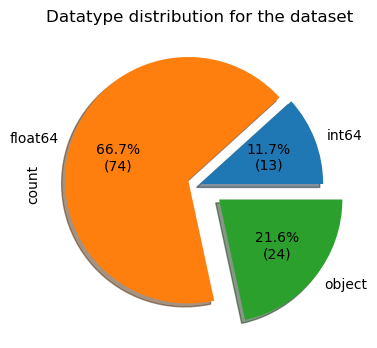

In [9]:
# lccs_df.dtypes.nunique()

plot_dtype_pie_chart()

In [10]:
# book-keeping: Remove leading and trailing space if present from column names
lccs_df.columns = lccs_df.columns.str.strip()

In [11]:
# Reaffirm the column and row count via shape call on the dataframe
lccs_df.shape

(39717, 111)

### <font color = green> <strong> Observations: </strong>
> 1. Dataset has 39717 rows and 111 columns
> 2. There are 12 columms with data belonging to 3 different types of datatypes
> 3. Datatype split among columns is as follows,<br>
            a. int64   -> 13<br>
            b. object  -> 24<br>
            c. float64 -> 74

***

## <center><font color = "blue"> Data Cleaning and Manipulation

### <font color = blue>Columns with only NULL values
- Columns with all rows being filled with NULL values do not help in any analysis
- Such columns needs to be removed/cleaned to reduce noise in the dataset

In [12]:
columns_null_value_only_list = lccs_df.columns[lccs_df.isnull().sum() == len(lccs_df)].to_list()

print(Fore.MAGENTA + "Columns with all null values: \n{}".format(columns_null_value_only_list))

# Remove columns with NULL only value
print(Fore.RED + "Before clean-up statistics (Remove NULL value only columns): Rows {}, Columns {}"
      .format(len(lccs_df),len(lccs_df.columns)))

print(Fore.YELLOW + "Total number of columns schedule for clean-up: {}"
      .format(len(columns_null_value_only_list)))

lccs_df=lccs_df.drop(columns=columns_null_value_only_list)   #Clean-up execution

print(Fore.GREEN + "After clean-up statistics (Remove NULL value only columns): Rows {}, Columns {}"
      .format(len(lccs_df),len(lccs_df.columns)))

Columns with all null values: 
['mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_il_6m', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc

In [13]:
# Confirm data-frame dimension
print("Shape of lending club dataset after clean-up of 'Only NULL value columns': {}".format(lccs_df.shape))

Shape of lending club dataset after clean-up of 'Only NULL value columns': (39717, 57)


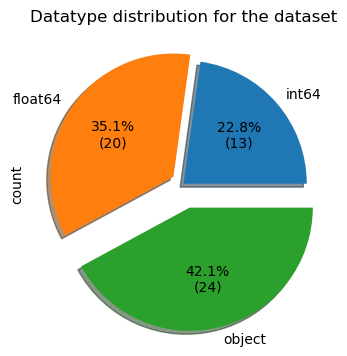

In [14]:
# Datatype distribution after removal of columns with only NULL values
plot_dtype_pie_chart()

#### <font color = green> <strong> Observations on 'Columns with only NULL values':</strong>
> 1. Dataset has 54 columns which consisted of null values for all the rows
> 2. These columns can hav eno value for our analysis and hence can be dropped
> 3. Once all the columns with only NULL values ae removed the number of columns comes down to 57

***

### <font color = blue> Columns with only one value (All same value)
- Columns populated with asingle value for all the rows do not aid in analysis
- Such columns needs to be removed to reduce noise in the dataset

In [15]:
columns_one_value_list = lccs_df.columns[lccs_df.nunique() == 1].to_list()

print(Fore.MAGENTA + "Columns with only one value: \n{}".format(columns_one_value_list))

# Remove columns with single value
print(Fore.RED + "Before clean-up statistics (Remove single value columns): Rows {}, Columns {}"
      .format(len(lccs_df),len(lccs_df.columns)))

print(Fore.YELLOW + "Total number of columns schedule for clean-up: {}"
      .format(len(columns_one_value_list)))

lccs_df=lccs_df.drop(columns=columns_one_value_list)   #Clean-up execution

print(Fore.GREEN + "After clean-up statistics (Remove single value columns): Rows {}, Columns {}"
      .format(len(lccs_df),len(lccs_df.columns)))

Columns with only one value: 
['pymnt_plan', 'initial_list_status', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'tax_liens']
Before clean-up statistics (Remove single value columns): Rows 39717, Columns 57
Total number of columns schedule for clean-up: 9
After clean-up statistics (Remove single value columns): Rows 39717, Columns 48


In [16]:
# Reaffirm the column and row count via shape call on the dataframe after single value columns clean-up
print("Shape of lending club dataset after clean-up of 'single value columns': {}".format(lccs_df.shape))

Shape of lending club dataset after clean-up of 'single value columns': (39717, 48)


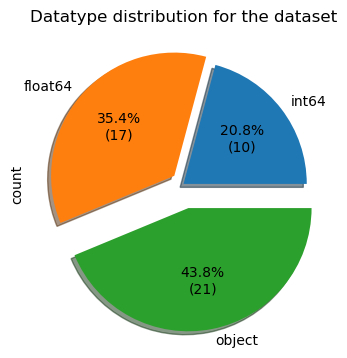

In [17]:
# Data type in the dataset after removal of columns with only one value for all rows
plot_dtype_pie_chart()

#### <font color = green> <strong> Observations on 'Columns with single value': </strong>
> 1. Dataset has 9 columns which consisted of single values for all the rows
> 2. These columns can have no value for our analysis and hence can be dropped
> 3. Once all the columns with only single valuee are removed the number of columns comes down to 48

***

### <font color = blue> Columns with all unique values
- Objective of the analysis is to understadn the behaviour of indiviudlas to decide on whether they woud defualt on the loans given or not.
- Since the objective involves analysing the overall behaviour of individuals in the dataset, individual level data analysis isn't required and hence columns with unique values for all rows can be neglected hence removed.

In [18]:
columns_all_unique_values_list = lccs_df.columns[lccs_df.nunique() >= len(lccs_df)].to_list()

print(Fore.MAGENTA + "Columns with all unique values: \n{}".format(columns_all_unique_values_list))

# Remove columns with all unique values
print(Fore.RED + "Before clean-up statistics (Remove all unique values columns): Rows {}, Columns {}"
      .format(len(lccs_df),len(lccs_df.columns)))

print(Fore.YELLOW + "Total number of columns schedule for clean-up: {}"
      .format(len(columns_all_unique_values_list)))

lccs_df=lccs_df.drop(columns=columns_all_unique_values_list)   #Clean-up execution

print(Fore.GREEN + "After clean-up statistics (Remove all unique values columns): Rows {}, Columns {}"
      .format(len(lccs_df),len(lccs_df.columns)))

Columns with all unique values: 
['id', 'member_id', 'url']
Before clean-up statistics (Remove all unique values columns): Rows 39717, Columns 48
Total number of columns schedule for clean-up: 3
After clean-up statistics (Remove all unique values columns): Rows 39717, Columns 45


In [19]:
# Reaffirm the column and row count via shape call on the dataframe after all unique values clean-up
print("Shape of lending club dataset after clean-up of 'columns with all unique values': {}".format(lccs_df.shape))

Shape of lending club dataset after clean-up of 'columns with all unique values': (39717, 45)


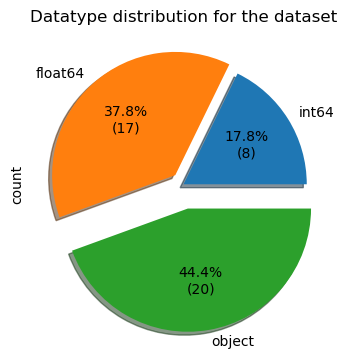

In [20]:
plot_dtype_pie_chart()

#### <font color = green> <strong> Observations on 'Columns with all unique values': </strong>
> 1. Dataset has 3 columns which consisted of all unique values for all the rows
> 2. These columns add no value for our analysis and hence can be dropped
> 3. Once all the columns with all unique values are removed the number of columns comes down to 45

***

### Sanity check to ensure that there aren't empty rows and columns in the dataset

In [21]:
# Check for emptiness

# Check for row emptiness
empty_row_count = lccs_df.isnull().all(axis=1).sum()

# Check for column emptiness
empty_column_count = lccs_df.isnull().all(axis=0).sum()

print("Emptiness check result: {} empty rows and {} empty columns".format(empty_row_count,empty_column_count))

Emptiness check result: 0 empty rows and 0 empty columns


***

### <font color = blue> Analyse each column to understand if it's relevant for our analysis and also if it needs any modifications

In [22]:
# pd.options.display.max_columns = len(lccs_df.columns)
lccs_df.head(3)

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,pub_rec_bankruptcies
0,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0,Jan-85,1,NaN,NaN,3,0,13648,83.70%,9,0.0,0.0,5863.155187,5833.84,5000.00,863.16,0.0,0.00,0.00,Jan-15,171.62,NaN,May-16,0.0
1,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0,Apr-99,5,NaN,NaN,3,0,1687,9.40%,4,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0
2,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,NaN,small_business,real estate business,606xx,IL,8.72,0,Nov-01,2,NaN,NaN,2,0,2956,98.50%,10,0.0,0.0,3005.666844,3005.67,2400.00,605.67,0.0,0.00,0.00,Jun-14,649.91,NaN,May-16,0.0


In [23]:
print(Fore.MAGENTA + "Columns in the dataframe: {}".format(lccs_df.columns))

Columns in the dataframe: Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'desc', 'purpose', 'title', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'next_pymnt_d', 'last_credit_pull_d', 'pub_rec_bankruptcies'],
      dtype='object')


In [24]:
lccs_df.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,pub_rec_bankruptcies
count,39717.000000,39717.000000,39717.000000,39717.000000,3.971700e+04,39717.000000,39717.000000,39717.000000,14035.000000,2786.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39717.000000,39020.000000
mean,11219.443815,10947.713196,10397.448868,324.561922,6.896893e+04,13.315130,0.146512,0.869200,35.900962,69.698134,9.294408,0.055065,13382.528086,22.088828,51.227887,50.989768,12153.596544,11567.149118,9793.348813,2263.663172,1.363015,95.221624,12.406112,2678.826162,0.043260
std,7456.670694,7187.238670,7128.450439,208.874874,6.379377e+04,6.678594,0.491812,1.070219,22.020060,43.822529,4.400282,0.237200,15885.016641,11.401709,375.172839,373.824457,9042.040766,8942.672613,7065.522127,2608.111964,7.289979,688.744771,148.671593,4447.136012,0.204324
min,500.000000,500.000000,0.000000,15.690000,4.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5500.000000,5400.000000,5000.000000,167.020000,4.040400e+04,8.170000,0.000000,0.000000,18.000000,22.000000,6.000000,0.000000,3703.000000,13.000000,0.000000,0.000000,5576.930000,5112.310000,4600.000000,662.180000,0.000000,0.000000,0.000000,218.680000,0.000000
50%,10000.000000,9600.000000,8975.000000,280.220000,5.900000e+04,13.400000,0.000000,1.000000,34.000000,90.000000,9.000000,0.000000,8850.000000,20.000000,0.000000,0.000000,9899.640319,9287.150000,8000.000000,1348.910000,0.000000,0.000000,0.000000,546.140000,0.000000
75%,15000.000000,15000.000000,14400.000000,430.780000,8.230000e+04,18.600000,0.000000,1.000000,52.000000,104.000000,12.000000,0.000000,17058.000000,29.000000,0.000000,0.000000,16534.433040,15798.810000,13653.260000,2833.400000,0.000000,0.000000,0.000000,3293.160000,0.000000
max,35000.000000,35000.000000,35000.000000,1305.190000,6.000000e+06,29.990000,11.000000,8.000000,120.000000,129.000000,44.000000,4.000000,149588.000000,90.000000,6311.470000,6307.370000,58563.679930,58563.680000,35000.020000,23563.680000,180.200000,29623.350000,7002.190000,36115.200000,2.000000


In [25]:
lccs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loan_amnt                39717 non-null  int64  
 1   funded_amnt              39717 non-null  int64  
 2   funded_amnt_inv          39717 non-null  float64
 3   term                     39717 non-null  object 
 4   int_rate                 39717 non-null  object 
 5   installment              39717 non-null  float64
 6   grade                    39717 non-null  object 
 7   sub_grade                39717 non-null  object 
 8   emp_title                37258 non-null  object 
 9   emp_length               38642 non-null  object 
 10  home_ownership           39717 non-null  object 
 11  annual_inc               39717 non-null  float64
 12  verification_status      39717 non-null  object 
 13  issue_d                  39717 non-null  object 
 14  loan_status           

In [26]:
lccs_df.shape

(39717, 45)

#### <font color = blue> Import dictionary with description for each column

In [27]:
# Check and evaluate each column for significance with respect to the objectives of the case study

# Import dictionary with description for each column

lccs_col_def_df = pd.read_excel('Data_Dictionary.xlsx', index_col=0, sheet_name='LoanStats')

lccs_col_def_df.sort_index(ascending=True,inplace=True)

lccs_col_def_df

,Description
LoanStatNew,
acc_now_delinq,The number of accounts on which the borrower i...
acc_open_past_24mths,Number of trades opened in past 24 months.
addr_state,The state provided by the borrower in the loan...
all_util,Balance to credit limit on all trades
annual_inc,The self-reported annual income provided by th...
...,...
verification_status,"Indicates if income was verified by LC, not ve..."
verified_status_joint,Indicates if the co-borrowers' joint income wa...
zip_code,The first 3 numbers of the zip code provided b...


***

#### <font color = blue> HeatMap on loan amount and funding columns

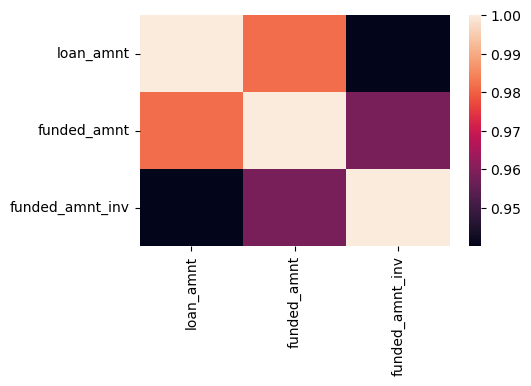

In [28]:
loan_amt_fund_columns = lccs_df[["loan_amnt","funded_amnt","funded_amnt_inv"]]

plt.figure(figsize=(5,3))
sns.heatmap(loan_amt_fund_columns.corr())
plt.show()

#### <font color = green> Observations on 'heatmap':
> 1. Strong correlation found between columns "loan_amnt","funded_amnt" and "funded_amnt_inv"
> 2. We can retain "loan_amnt" and drop the other two. Further analysis below

#### <font color = blue> Analysing column "funded_amnt"

In [29]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'funded_amnt': {}".format(lccs_col_def_df.loc["funded_amnt",
                                                                                              "Description"]))

# To analyse the defaulting behaviour of the borrower, the "funded_amt" column does not provide any insight that
# the column "loan_amnt" could not.

# Cleaning actions for "funded_amnt":
#     1. Drop the column "funded_amnt"

lccs_df.drop(columns="funded_amnt", inplace=True)

Definition of column 'funded_amnt': The total amount committed to that loan at that point in time.


***

#### <font color = blue> Analysing column "funded_amnt_inv"

In [30]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'funded_amnt_inv': {}".format(lccs_col_def_df.loc["funded_amnt_inv",
                                                                                                  "Description"]))

# To analyse the defaulting behaviour of the borrower, the "funded_amt" column does not provide any insight that
# the column "loan_amnt" could not.

# Cleaning actions for "funded_amnt_inv":
#     1. Drop the column "funded_amnt_inv"

lccs_df.drop(columns="funded_amnt_inv", inplace=True)

Definition of column 'funded_amnt_inv': The total amount committed by investors for that loan at that point in time.


***

#### <font color = blue>  Analysing column "term"

In [31]:
print(Fore.LIGHTBLUE_EX + "Definition of column \"term\": {}".format(lccs_col_def_df.loc["term",
                                                                                         "Description"]))
print(Fore.RESET +"Datatype of column 'term' before cleansing: {}".format(lccs_df["term"].dtype))

# As per definition the column "term" can have value either 36 or 60.
#     1. Check if there are any value outside of the permitted values
#     2. Convert the values to reflect integers
#     3. Convert "term" column's datatype from Object to int64

# Strip trailing "months" string from each row value and convert to int64 type
lccs_df["term"] = lccs_df["term"].apply(lambda x: int(x.rstrip("months")))

#  Verify that only 2 permitted values are populated
print("Value and it's count for column 'term': {}".format(lccs_df["term"].value_counts().to_dict()))

print("Datatype of column 'term' after cleansing: {}".format(lccs_df["term"].dtype))

Definition of column "term": The number of payments on the loan. Values are in months and can be either 36 or 60.
Datatype of column 'term' before cleansing: object
Value and it's count for column 'term': {36: 29096, 60: 10621}
Datatype of column 'term' after cleansing: int64


***

#### <font color = blue> Analysing column "int_rate"

In [32]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'int_rate': {}".format(lccs_col_def_df.loc["int_rate",
                                                                                           "Description"]))
print(Fore.RESET + "Datatype of column 'int_rate' before cleansing: {}".format(lccs_df["int_rate"].dtype))

# Cleaning actions for "int_rate":
#     1. Remove trailing "%"
#     2. Convert "int_rate" column's datatype from Object to int64

# # Strip trailing "%" from each row value and convert to int64 type
lccs_df["int_rate"] = lccs_df["int_rate"].apply(lambda x: float(x.rstrip("%")))

print("Datatype of column 'int_rate' after cleansing: {}".format(lccs_df["int_rate"].dtype))

Definition of column 'int_rate': Interest Rate on the loan
Datatype of column 'int_rate' before cleansing: object
Datatype of column 'int_rate' after cleansing: float64


***

#### <font color = blue> Analysing column "emp_title"

In [33]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'emp_title': {}".format(lccs_col_def_df.loc["emp_title",
                                                                                            "Description"]))
print(Fore.RESET + "Number of unique values for column 'emp_title': {}".format(len(lccs_df["emp_title"].value_counts().to_dict())))

# This is a user specified field and the values are not normalised.
# As per analysis there are 28820 unique values for this column

# Cleaning actions for "emp_title":
#     1. Drop column "emp_title"

lccs_df.drop(columns="emp_title", inplace=True)

Definition of column 'emp_title': The job title supplied by the Borrower when applying for the loan.*
Number of unique values for column 'emp_title': 28820


***

#### <font color = blue> Analysing column "emp_length"

In [34]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'emp_length': {}".format(lccs_col_def_df.loc["emp_length",
                                                                                             "Description"]))
print(Fore.RESET + "Datatype of column 'emp_length' before cleansing: {}".format(lccs_df["emp_length"].dtype))

# Cleaning actions for "emp_length":
#     1. Extract integer value for column "emp_length"
#     2. Convert type to int64

# Strip trailing "months" string from each row value and convert to int64 type
lccs_df = lccs_df.assign(emp_length = lambda x: x['emp_length'].str.extract('(\d+)'))

lccs_df["emp_length"] = lccs_df["emp_length"].fillna(0).astype("int64")

print("Value and it's count for column 'emp_length': {}".format(lccs_df["emp_length"].value_counts().to_dict()))

print("Datatype of column 'emp_length' after cleansing: {}".format(lccs_df["emp_length"].dtype))

Definition of column 'emp_length': Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years. 
Datatype of column 'emp_length' before cleansing: object
Value and it's count for column 'emp_length': {10: 8879, 1: 7823, 2: 4388, 3: 4095, 4: 3436, 5: 3282, 6: 2229, 7: 1773, 8: 1479, 9: 1258, 0: 1075}
Datatype of column 'emp_length' after cleansing: int64


***

#### <font color = blue> Analysing column "desc"

In [35]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'desc': {}".format(lccs_col_def_df.loc["desc","Description"]))
print(Fore.RESET + "Number of unique values for column 'desc': {}".format(len(lccs_df["desc"].unique())))

# As per the definition, the details for this column ios borrower provided and follows no specific format.
# Also, the number of unique value count is 26,528 which is about 66% of the total row count

# # Cleaning actions for "desc":
# #     1. Drop column "desc"

lccs_df.drop(columns="desc", inplace=True)

Definition of column 'desc': Loan description provided by the borrower
Number of unique values for column 'desc': 26528


***

#### <font color = blue> Analysing column "title"

In [36]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'title': {}".format(lccs_col_def_df.loc["title","Description"]))
print(Fore.RESET + "Number of unique values for column 'title': {}".format(len(lccs_df["title"].unique())))

# The number of unique value count is 26,528 which is close to 50% of the total row count
# Relevant information can be picked up from similar column "purpose"

# # Cleaning actions for "title":
# #     1. Drop column "title"

lccs_df.drop(columns="title", inplace=True)

Definition of column 'title': The loan title provided by the borrower
Number of unique values for column 'title': 19616


***

#### <font color = blue> Analysing column "zip_code"

In [37]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'zip_code': {}".format(lccs_col_def_df.loc["zip_code",
                                                                                           "Description"]))
print(Fore.RESET + "Number of unique values for column 'zip_code': {}".format(len(lccs_df["zip_code"].unique())))

# The number of unique value count is 823 which is 2% of the total row count making this column look relevant
# but same information or similar one can be drawn from the column "addr_state". Retaining this column also
# does not make sense as the last 2 digits are masked for all the rows.

# # Cleaning actions for "zip_code":
# #     1. Drop column "zip_code" 

lccs_df.drop(columns="zip_code", inplace=True)

Definition of column 'zip_code': The first 3 numbers of the zip code provided by the borrower in the loan application.
Number of unique values for column 'zip_code': 823


***

#### <font color = blue> Analysing column "mths_since_last_delinq"

In [38]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'mths_since_last_delinq': {}"
      .format(lccs_col_def_df.loc["mths_since_last_delinq","Description"]))

print(Fore.RESET + "Number of unique values for column 'mths_since_last_delinq': {}"
      .format(len(lccs_df["mths_since_last_delinq"].unique())))

print("Missing values for column 'mths_since_last_delinq': {}"
      .format(lccs_df["mths_since_last_delinq"].isnull().sum()))

# Retaining this column does not make sense as close to 65% of the rows have null values.

# # Cleaning actions for "mths_since_last_delinq":
# #     1. Drop column "mths_since_last_delinq" 

lccs_df.drop(columns="mths_since_last_delinq", inplace=True)

Definition of column 'mths_since_last_delinq': The number of months since the borrower's last delinquency.
Number of unique values for column 'mths_since_last_delinq': 96
Missing values for column 'mths_since_last_delinq': 25682


***

#### <font color = blue> Analysing column "mths_since_last_record"

In [39]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'mths_since_last_record': {}"
      .format(lccs_col_def_df.loc["mths_since_last_record","Description"]))

print(Fore.RESET + "Number of unique values for column 'mths_since_last_record': {}"
      .format(len(lccs_df["mths_since_last_record"].unique())))

print("Missing values for column 'mths_since_last_record': {}".format(lccs_df["mths_since_last_record"].isnull().sum()))

# Retaining this column does not make sense as close to 92% of the rows have null values.

# # Cleaning actions for "mths_since_last_record":
# #     1. Drop column "mths_since_last_record" 

lccs_df.drop(columns="mths_since_last_record", inplace=True)

Definition of column 'mths_since_last_record': The number of months since the last public record.
Number of unique values for column 'mths_since_last_record': 112
Missing values for column 'mths_since_last_record': 36931


***

#### <font color = blue> Analysing column "earliest_cr_line"

In [40]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'earliest_cr_line': {}"
      .format(lccs_col_def_df.loc["earliest_cr_line","Description"]))

print(Fore.RESET + "Number of unique values for column 'earliest_cr_line': {}"
      .format(len(lccs_df["earliest_cr_line"].unique())))

# As per the understadnong, this reflects the behaviour of the birrower to take credit. The data includes those which
# date to pre 1995 years. Might not be affect our analysis as the loans under analysis are mroe recent as in after 2005

# # Cleaning actions for "earliest_cr_line":
# #     1. Drop column "earliest_cr_line" 

lccs_df.drop(columns="earliest_cr_line", inplace=True)

Definition of column 'earliest_cr_line': The month the borrower's earliest reported credit line was opened
Number of unique values for column 'earliest_cr_line': 526


***

#### <font color = blue> Analysing column "revol_util"

In [41]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'revol_util': {}"
      .format(lccs_col_def_df.loc["revol_util","Description"]))

print(Fore.RESET + "Datatype of column 'revol_util' before cleansing: {}".format(lccs_df["revol_util"].dtype))

# Cleaning actions for "title":
#     1. Strip the trailing '%'
#     2. Convert the datatype from object to float64

lccs_df["revol_util"]=lccs_df["revol_util"].apply(lambda x: float(str(x).rstrip('%')))
print("Datatype of column 'revol_util' after cleansing: {}".format(lccs_df["revol_util"].dtype))

Definition of column 'revol_util': Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
Datatype of column 'revol_util' before cleansing: object
Datatype of column 'revol_util' after cleansing: float64


***

#### <font color = blue> Analysing column "out_prncp"

In [42]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'out_prncp': {}".format(lccs_col_def_df.loc["out_prncp",
                                                                                            "Description"]))

# When the borrower has already defaulted, it shouldn't matter how much is the principle amount to be paid.
# Cleaning actions for "out_prncp":
#     1. Drop the column "out_prncp"

lccs_df.drop(columns="out_prncp", inplace=True)

Definition of column 'out_prncp': Remaining outstanding principal for total amount funded


***

#### <font color = blue> Analysing column "out_prncp_inv"

In [43]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'out_prncp_inv': {}"
      .format(lccs_col_def_df.loc["out_prncp_inv","Description"]))

# When the borrower has already defaulted, it shouldn't matter how much is the principle amount to be paid even
# if it towards the amount funded byt he investors.

# Cleaning actions for "out_prncp_inv":
#     1. Drop the column "out_prncp_inv"

lccs_df.drop(columns="out_prncp_inv", inplace=True)

Definition of column 'out_prncp_inv': Remaining outstanding principal for portion of total amount funded by investors


***

#### <font color = blue> Analysing column "total_pymnt"

In [44]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'total_pymnt': {}".format(lccs_col_def_df.loc["total_pymnt",
                                                                                              "Description"]))

# If the borrower has already defaulted would not matter what amount as already been paid as the next
# installments are defaulted. Also, for our analysis, the already paid amount would not provide any insights

# Cleaning actions for "total_pymnt":
#     1. Drop the column "total_pymnt"

lccs_df.drop(columns="total_pymnt", inplace=True)

Definition of column 'total_pymnt': Payments received to date for total amount funded


***

#### <font color = blue> Analysing column "total_pymnt_inv"

In [45]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'total_pymnt_inv': {}"
      .format(lccs_col_def_df.loc["total_pymnt_inv","Description"]))

# If the borrower has already defaulted would not matter what amount as already been paid towards investor
# funded amount as the next installments are defaulted. Also, for our analysis, the already paid amount
# would not provide any insights

# Cleaning actions for "total_pymnt_inv":
#     1. Drop the column "total_pymnt_inv"

lccs_df.drop(columns="total_pymnt_inv", inplace=True)

Definition of column 'total_pymnt_inv': Payments received to date for portion of total amount funded by investors


***

#### <font color = blue> Analysing column "total_rec_prncp"

In [46]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'total_rec_prncp': {}"
      .format(lccs_col_def_df.loc["total_rec_prncp","Description"]))

# If the borrower has already defaulted would not matter what principal amount as already been paid as the next
# installments are defaulted. Also, for our analysis, the already paid principle amount would not provide any
# insights

# Cleaning actions for "total_rec_prncp":
#     1. Drop the column "total_rec_prncp"

lccs_df.drop(columns="total_rec_prncp", inplace=True)

Definition of column 'total_rec_prncp': Principal received to date


***

#### <font color = blue> Analysing column "total_rec_int"

In [47]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'total_rec_int': {}"
      .format(lccs_col_def_df.loc["total_rec_int","Description"]))

# If the borrower has already defaulted would not matter what interest amount as already been paid as the next
# installments are defaulted. Also, for our analysis, the already paid interest amount would not provide any
# insights

# Cleaning actions for "total_rec_int":
#     1. Drop the column "total_rec_int"

lccs_df.drop(columns="total_rec_int", inplace=True)

Definition of column 'total_rec_int': Interest received to date


***

#### <font color = blue> Analysing column "total_rec_late_fee"

In [48]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'total_rec_late_fee': {}"
      .format(lccs_col_def_df.loc["total_rec_late_fee","Description"]))

# If the borrower has already defaulted would not matter what late fees amount has been paid. Also, for our
# analysis, the late fees received amount would not provide any insights

# Cleaning actions for "total_rec_late_fee":
#     1. Drop the column "total_rec_late_fee"

lccs_df.drop(columns="total_rec_late_fee", inplace=True)

Definition of column 'total_rec_late_fee': Late fees received to date


***

#### <font color = blue> Analysing column "next_pymnt_d"

In [49]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'next_pymnt_d': {}".
      format(lccs_col_def_df.loc["next_pymnt_d","Description"]))

# Goal is to identify the behaviour of defaulters. If the borrower has already defaulted next scheduled payment
# date carries not much value as it would nto provide us any valuable insight for our analysis.

# Cleaning actions for "next_pymnt_d":
#     1. Drop the column "next_pymnt_d"

lccs_df.drop(columns="next_pymnt_d", inplace=True)

Definition of column 'next_pymnt_d': Next scheduled payment date


***

#### <font color = blue> Analysing column "last_credit_pull_d"

In [50]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'last_credit_pull_d': {}"
      .format(lccs_col_def_df.loc["last_credit_pull_d","Description"]))

# For a dafaulter, even the recent crdit report would not provide any isght on the behaviour. Adds no value
# to our analysis.

# Cleaning actions for "last_credit_pull_d":
#     1. Drop the column "last_credit_pull_d"

lccs_df.drop(columns="last_credit_pull_d", inplace=True)

Definition of column 'last_credit_pull_d': The most recent month LC pulled credit for this loan


***

#### <font color = blue> Analysing column "loan_status"

In [51]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'last_credit_pull_d': {}"
      .format(lccs_col_def_df.loc["last_credit_pull_d","Description"]))

print(Fore.RESET + "Shape of the dataset before cleaning for 'loan_status': {}".format(lccs_df.shape))

# "loan_status" equal to 'Current' does not give any information which would allow us to approve or reject
# the future loan applications. Drop rows with loan_status equal to 'Current' from the analysis

# Cleaning actions for "loan_status":
#     1. Remove rows with loan_status equal to "current"

lccs_df = lccs_df[~(lccs_df["loan_status"] == "Current")]
print("Shape of the dataset after cleaning for 'loan_status': {}".format(lccs_df.shape))

Definition of column 'last_credit_pull_d': The most recent month LC pulled credit for this loan
Shape of the dataset before cleaning for 'loan_status': (39717, 27)
Shape of the dataset after cleaning for 'loan_status': (38577, 27)


***

#### <font color = blue> Analysing column "inq_last_6mths"

In [52]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'inq_last_6mths': {}".format(lccs_col_def_df.loc["inq_last_6mths","Description"]))

# Since this columns informa about the number of enquiries made, it is more to do with individual analysis
# Cleaning actions for "inq_last_6mths":
#     1. Drop column "inq_last_6mths"

lccs_df.drop(columns="inq_last_6mths", inplace=True)

Definition of column 'inq_last_6mths': The number of inquiries in past 6 months (excluding auto and mortgage inquiries)


***

#### <font color = blue> Analysing column "recoveries"

In [53]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'recoveries': {}".format(lccs_col_def_df.loc["recoveries",
                                                                                             "Description"]))

# The data in this column opertains to loans that have already been defaulted
# Cleaning actions for "recoveries":
#     1. Drop column "recoveries"

lccs_df.drop(columns="recoveries", inplace=True)

Definition of column 'recoveries': post charge off gross recovery


***

#### <font color = blue> Analysing column "collection_recovery_fee"

In [54]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'collection_recovery_fee': {}"
      .format(lccs_col_def_df.loc["collection_recovery_fee","Description"]))

# The data in this column opertains to loans that have already been defaulted
# Cleaning actions for "collection_recovery_fee":
#     1. Drop column "collection_recovery_fee"

lccs_df.drop(columns="collection_recovery_fee", inplace=True)

Definition of column 'collection_recovery_fee': post charge off collection fee


***

#### <font color = blue> Analysing column "last_pymnt_d"

In [55]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'last_pymnt_d': {}"
      .format(lccs_col_def_df.loc["last_pymnt_d","Description"]))

# For default loan, the last payment date adds no value to out analysis
# Cleaning actions for "last_pymnt_d":
#     1. Drop column "last_pymnt_d"

lccs_df.drop(columns="last_pymnt_d", inplace=True)

Definition of column 'last_pymnt_d': Last month payment was received


***

#### <font color = blue> Analysing column "last_pymnt_amnt"

In [56]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'last_pymnt_amnt': {}"
      .format(lccs_col_def_df.loc["last_pymnt_amnt","Description"]))

# For default loan, the last payment amount adds no value to out analysis
# Cleaning actions for "last_pymnt_amnt":
#     1. Drop column "last_pymnt_amnt"

lccs_df.drop(columns="last_pymnt_amnt", inplace=True)

Definition of column 'last_pymnt_amnt': Last total payment amount received


***

In [57]:
print("Shape of dataframe after analysing each column: {}".format(lccs_df.shape))

Shape of dataframe after analysing each column: (38577, 22)


In [58]:
lccs_df.describe()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies
count,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,3.857700e+04,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38527.000000,38577.000000,37880.000000
mean,11047.025430,41.898437,11.932219,322.466318,4.925526,6.877797e+04,13.272727,0.146668,9.275423,0.055422,13289.489826,48.702777,22.052648,0.043479
std,7348.441646,10.333136,3.691327,208.639215,3.453921,6.421868e+04,6.673044,0.492271,4.401588,0.237804,15866.492241,28.364741,11.425861,0.204583
min,500.000000,36.000000,5.420000,15.690000,0.000000,4.000000e+03,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,5300.000000,36.000000,8.940000,165.740000,2.000000,4.000000e+04,8.130000,0.000000,6.000000,0.000000,3650.000000,25.200000,13.000000,0.000000
50%,9600.000000,36.000000,11.710000,277.860000,4.000000,5.886800e+04,13.370000,0.000000,9.000000,0.000000,8762.000000,49.100000,20.000000,0.000000
75%,15000.000000,36.000000,14.380000,425.550000,9.000000,8.200000e+04,18.560000,0.000000,12.000000,0.000000,16912.000000,72.300000,29.000000,0.000000
max,35000.000000,60.000000,24.400000,1305.190000,10.000000,6.000000e+06,29.990000,11.000000,44.000000,4.000000,149588.000000,99.900000,90.000000,2.000000


In [59]:
lccs_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38577 entries, 0 to 39716
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             38577 non-null  int64  
 1   term                  38577 non-null  int64  
 2   int_rate              38577 non-null  float64
 3   installment           38577 non-null  float64
 4   grade                 38577 non-null  object 
 5   sub_grade             38577 non-null  object 
 6   emp_length            38577 non-null  int64  
 7   home_ownership        38577 non-null  object 
 8   annual_inc            38577 non-null  float64
 9   verification_status   38577 non-null  object 
 10  issue_d               38577 non-null  object 
 11  loan_status           38577 non-null  object 
 12  purpose               38577 non-null  object 
 13  addr_state            38577 non-null  object 
 14  dti                   38577 non-null  float64
 15  delinq_2yrs        

In [60]:
lccs_df.head(7)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies
0,5000,36,10.65,162.87,B,B2,10,RENT,24000.0,Verified,Dec-11,Fully Paid,credit_card,AZ,27.65,0,3,0,13648,83.7,9,0.0
1,2500,60,15.27,59.83,C,C4,1,RENT,30000.0,Source Verified,Dec-11,Charged Off,car,GA,1.00,0,3,0,1687,9.4,4,0.0
2,2400,36,15.96,84.33,C,C5,10,RENT,12252.0,Not Verified,Dec-11,Fully Paid,small_business,IL,8.72,0,2,0,2956,98.5,10,0.0
3,10000,36,13.49,339.31,C,C1,10,RENT,49200.0,Source Verified,Dec-11,Fully Paid,other,CA,20.00,0,10,0,5598,21.0,37,0.0
5,5000,36,7.90,156.46,A,A4,3,RENT,36000.0,Source Verified,Dec-11,Fully Paid,wedding,AZ,11.20,0,9,0,7963,28.3,12,0.0
6,7000,60,15.96,170.08,C,C5,8,RENT,47004.0,Not Verified,Dec-11,Fully Paid,debt_consolidation,NC,23.51,0,7,0,17726,85.6,11,0.0
7,3000,36,18.64,109.43,E,E1,9,RENT,48000.0,Source Verified,Dec-11,Fully Paid,car,CA,5.35,0,4,0,8221,87.5,4,0.0


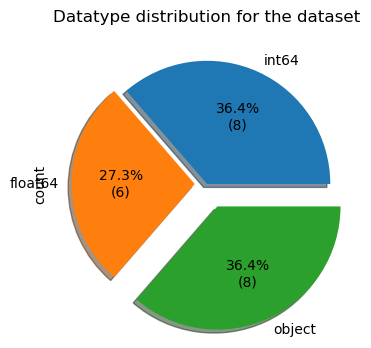

In [61]:
plot_dtype_pie_chart()

## <font color = green> Observations after cleaning the dataset (With derieved columns pending):
> 1. Dataframe now consists of 22 columns and 38577 rows
> 2. Column datatype distribution: 8 - int64, 8 - object, 6 - float64

#### <font color = blue> DERIEVED COLUMNS

#### <font color = blue> Analysing column "issue_d"

In [62]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'issue_d': {}".format(lccs_col_def_df.loc["issue_d","Description"]))

print(Fore.RESET + "Shape of the data frame before deriving columns from 'issue_d': {}"
      .format(lccs_df.shape))
# Cleaning actions for "emp_length":
#     1. Split the value to month and year columns
#     2. Drop column "issue_d"

lccs_df["issue_year"] = pd.to_datetime(lccs_df["issue_d"],format="%b-%y").dt.year
lccs_df["issue_month"] = pd.to_datetime(lccs_df["issue_d"],format="%b-%y").dt.month
print("Shape of the data frame after deriving columns from 'issue_d': {}"
      .format(lccs_df.shape))

lccs_df.drop(columns="issue_d", inplace=True)

print("Shape of the data frame after dropping column 'issue_d': {}".format(lccs_df.shape))

Definition of column 'issue_d': The month which the loan was funded
Shape of the data frame before deriving columns from 'issue_d': (38577, 22)
Shape of the data frame after deriving columns from 'issue_d': (38577, 24)
Shape of the data frame after dropping column 'issue_d': (38577, 23)


***

#### <font color = blue> Analysing column "int_rate"

In [63]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'int_rate': {}".format(lccs_col_def_df.loc["int_rate","Description"]))

print(Fore.LIGHTBLUE_EX + "Minimum and Maximum interest rate charged: Min is {} and Max is {}"
      .format(lccs_df["int_rate"].min(), lccs_df["int_rate"].max()))

# BREAK THE INTEREST RATE TO 10 slabs - 2.5 interval
lccs_df["int_rate_slabs"] = pd.cut(lccs_df['int_rate'], [5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0, 22.5, 25.0], 
                                   labels=["5.0-7.5", "7.5-10.0", "10.0-12.5", "12.5-15.0", "15.0-17.5",
                                           "17.5-20.0", "20.0-22.5","22.5-25.0"])

Definition of column 'int_rate': Interest Rate on the loan
Minimum and Maximum interest rate charged: Min is 5.42 and Max is 24.4


***

#### <font color = blue> Analysing column "loan_amnt"

In [64]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'loan_amnt': {}".format(lccs_col_def_df.loc["loan_amnt","Description"]))

print(Fore.LIGHTBLUE_EX + "Minimum and Maximum loan amount: Min is {} and Max is {}"
      .format(lccs_df["loan_amnt"].min(), lccs_df["loan_amnt"].max()))

# BREAK THE LOAN AMOUNT TO 7 slabs - 7000 interval
lccs_df['loan_amnt_slabs'] = pd.cut(lccs_df['loan_amnt'], [0, 7000, 14000, 21000, 28000, 35000], 
                                    labels=["0-7000", "7000-14000", "14000-21000", "21000-28000", "28000-35000"])

Definition of column 'loan_amnt': The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
Minimum and Maximum loan amount: Min is 500 and Max is 35000


***

#### <font color = blue> Analysing column "annual_inc"

In [65]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'annual_inc': {}".format(lccs_col_def_df.loc["annual_inc","Description"]))

print(Fore.LIGHTBLUE_EX + "Minimum and Maximum annual income of the borrower: Min is {} and Max is {}"
      .format(lccs_df["annual_inc"].min(),lccs_df["annual_inc"].max()))

# BREAK THE ANNUAL INCREMENT TO 7 slabs
lccs_df['annual_inc_slabs'] = pd.cut(lccs_df['annual_inc'], [0, 15000, 30000, 45000, 60000, 75000, 90000,
                                                            6000000], 
                                 labels=["0-15000", "15000-30000", "30000-45000", "45000-60000", 
                                         "60000-75000","75000-90000","90000+"])

Definition of column 'annual_inc': The self-reported annual income provided by the borrower during registration.
Minimum and Maximum annual income of the borrower: Min is 4000.0 and Max is 6000000.0


***

#### <font color = blue> Analysing column "dti"

In [66]:
print(Fore.LIGHTBLUE_EX + "Definition of column 'dti': {}".format(lccs_col_def_df.loc["dti","Description"]))

print(Fore.LIGHTBLUE_EX + "Minimum and Maximum annual income of the borrower: Min is {} and Max is {}"
      .format(lccs_df["dti"].min(),lccs_df["dti"].max()))

# BREAK THE ANNUAL INCREMENT TO 6 slabs - 5 interval

lccs_df['dti_slabs'] = pd.cut(lccs_df['dti'], [0, 5, 10, 15, 20, 25, 30], 
                           labels=["0-5", "5-10", "10-15", "15-20", "20-25","25-30"])

Definition of column 'dti': A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LC loan, divided by the borrower’s self-reported monthly income.
Minimum and Maximum annual income of the borrower: Min is 0.0 and Max is 29.99


***

#### <font color = blue> Statistics after analysing all the columns

In [67]:
# Head data
lccs_df.head(7)

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies,issue_year,issue_month,int_rate_slabs,loan_amnt_slabs,annual_inc_slabs,dti_slabs
0,5000,36,10.65,162.87,B,B2,10,RENT,24000.0,Verified,Fully Paid,credit_card,AZ,27.65,0,3,0,13648,83.7,9,0.0,2011,12,10.0-12.5,0-7000,15000-30000,25-30
1,2500,60,15.27,59.83,C,C4,1,RENT,30000.0,Source Verified,Charged Off,car,GA,1.00,0,3,0,1687,9.4,4,0.0,2011,12,15.0-17.5,0-7000,15000-30000,0-5
2,2400,36,15.96,84.33,C,C5,10,RENT,12252.0,Not Verified,Fully Paid,small_business,IL,8.72,0,2,0,2956,98.5,10,0.0,2011,12,15.0-17.5,0-7000,0-15000,5-10
3,10000,36,13.49,339.31,C,C1,10,RENT,49200.0,Source Verified,Fully Paid,other,CA,20.00,0,10,0,5598,21.0,37,0.0,2011,12,12.5-15.0,7000-14000,45000-60000,15-20
5,5000,36,7.90,156.46,A,A4,3,RENT,36000.0,Source Verified,Fully Paid,wedding,AZ,11.20,0,9,0,7963,28.3,12,0.0,2011,12,7.5-10.0,0-7000,30000-45000,10-15
6,7000,60,15.96,170.08,C,C5,8,RENT,47004.0,Not Verified,Fully Paid,debt_consolidation,NC,23.51,0,7,0,17726,85.6,11,0.0,2011,12,15.0-17.5,0-7000,45000-60000,20-25
7,3000,36,18.64,109.43,E,E1,9,RENT,48000.0,Source Verified,Fully Paid,car,CA,5.35,0,4,0,8221,87.5,4,0.0,2011,12,17.5-20.0,0-7000,45000-60000,5-10


In [68]:
# Row and Column count
print(Fore.LIGHTBLUE_EX + "Rows and columns of the dataframe: {}, {}".format(len(lccs_df),len(lccs_df.columns)))

Rows and columns of the dataframe: 38577, 27


In [69]:
lccs_df.describe()

,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies,issue_year,issue_month
count,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,3.857700e+04,38577.000000,38577.000000,38577.000000,38577.000000,38577.000000,38527.000000,38577.000000,37880.000000,38577.000000,38577.000000
mean,11047.025430,41.898437,11.932219,322.466318,4.925526,6.877797e+04,13.272727,0.146668,9.275423,0.055422,13289.489826,48.702777,22.052648,0.043479,2010.309070,7.114757
std,7348.441646,10.333136,3.691327,208.639215,3.453921,6.421868e+04,6.673044,0.492271,4.401588,0.237804,15866.492241,28.364741,11.425861,0.204583,0.882658,3.408523
min,500.000000,36.000000,5.420000,15.690000,0.000000,4.000000e+03,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,2007.000000,1.000000
25%,5300.000000,36.000000,8.940000,165.740000,2.000000,4.000000e+04,8.130000,0.000000,6.000000,0.000000,3650.000000,25.200000,13.000000,0.000000,2010.000000,4.000000
50%,9600.000000,36.000000,11.710000,277.860000,4.000000,5.886800e+04,13.370000,0.000000,9.000000,0.000000,8762.000000,49.100000,20.000000,0.000000,2011.000000,7.000000
75%,15000.000000,36.000000,14.380000,425.550000,9.000000,8.200000e+04,18.560000,0.000000,12.000000,0.000000,16912.000000,72.300000,29.000000,0.000000,2011.000000,10.000000
max,35000.000000,60.000000,24.400000,1305.190000,10.000000,6.000000e+06,29.990000,11.000000,44.000000,4.000000,149588.000000,99.900000,90.000000,2.000000,2011.000000,12.000000


In [70]:
lccs_df

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,delinq_2yrs,open_acc,pub_rec,revol_bal,revol_util,total_acc,pub_rec_bankruptcies,issue_year,issue_month,int_rate_slabs,loan_amnt_slabs,annual_inc_slabs,dti_slabs
0,5000,36,10.65,162.87,B,B2,10,RENT,24000.0,Verified,Fully Paid,credit_card,AZ,27.65,0,3,0,13648,83.7,9,0.0,2011,12,10.0-12.5,0-7000,15000-30000,25-30
1,2500,60,15.27,59.83,C,C4,1,RENT,30000.0,Source Verified,Charged Off,car,GA,1.00,0,3,0,1687,9.4,4,0.0,2011,12,15.0-17.5,0-7000,15000-30000,0-5
2,2400,36,15.96,84.33,C,C5,10,RENT,12252.0,Not Verified,Fully Paid,small_business,IL,8.72,0,2,0,2956,98.5,10,0.0,2011,12,15.0-17.5,0-7000,0-15000,5-10
3,10000,36,13.49,339.31,C,C1,10,RENT,49200.0,Source Verified,Fully Paid,other,CA,20.00,0,10,0,5598,21.0,37,0.0,2011,12,12.5-15.0,7000-14000,45000-60000,15-20
5,5000,36,7.90,156.46,A,A4,3,RENT,36000.0,Source Verified,Fully Paid,wedding,AZ,11.20,0,9,0,7963,28.3,12,0.0,2011,12,7.5-10.0,0-7000,30000-45000,10-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,2500,36,8.07,78.42,A,A4,4,MORTGAGE,110000.0,Not Verified,Fully Paid,home_improvement,CO,11.33,0,13,0,7274,13.1,40,NaN,2007,7,7.5-10.0,0-7000,90000+,10-15
39713,8500,36,10.28,275.38,C,C1,3,RENT,18000.0,Not Verified,Fully Paid,credit_card,NC,6.40,1,6,0,8847,26.9,9,NaN,2007,7,10.0-12.5,7000-14000,15000-30000,5-10
39714,5000,36,8.07,156.84,A,A4,1,MORTGAGE,100000.0,Not Verified,Fully Paid,debt_consolidation,MA,2.30,0,11,0,9698,19.4,20,NaN,2007,7,7.5-10.0,0-7000,90000+,0-5
39715,5000,36,7.43,155.38,A,A2,1,MORTGAGE,200000.0,Not Verified,Fully Paid,other,MD,3.72,0,17,0,85607,0.7,26,NaN,2007,7,5.0-7.5,0-7000,90000+,0-5


In [71]:
lccs_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38577 entries, 0 to 39716
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   loan_amnt             38577 non-null  int64   
 1   term                  38577 non-null  int64   
 2   int_rate              38577 non-null  float64 
 3   installment           38577 non-null  float64 
 4   grade                 38577 non-null  object  
 5   sub_grade             38577 non-null  object  
 6   emp_length            38577 non-null  int64   
 7   home_ownership        38577 non-null  object  
 8   annual_inc            38577 non-null  float64 
 9   verification_status   38577 non-null  object  
 10  loan_status           38577 non-null  object  
 11  purpose               38577 non-null  object  
 12  addr_state            38577 non-null  object  
 13  dti                   38577 non-null  float64 
 14  delinq_2yrs           38577 non-null  int64   
 15  op

## <font color = green> Observations after cleaning the dataset:
> 1. Dataframe now consists of 27 columns and 38577 rows
> 2. Column dattaype distribution: 10 - int64, 7 - object, 6 - float64 and 4 category datatyped columns

***

## <center><font color="green"> EDA - Exploratory Data Analysis</font>

### <center> <font color = purple> UNIVARIATE Analysis - Continous/Numerial columns

>>> ### <font color = blue> Univariate analysis of loan_amnt (Loan Amount)

In [72]:
# Describe the column to understand the stats
lccs_df["loan_amnt"].describe()

count    38577.000000
mean     11047.025430
std       7348.441646
min        500.000000
25%       5300.000000
50%       9600.000000
75%      15000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

In [73]:
loan_amnt_df = lccs_df.loc[:,["loan_amnt","loan_amnt_slabs"]]
loan_amnt_df["loan_amnt_slabs"].value_counts()

0-7000         14307
7000-14000     13298
14000-21000     7041
21000-28000     2790
28000-35000     1141
Name: loan_amnt_slabs, dtype: int64

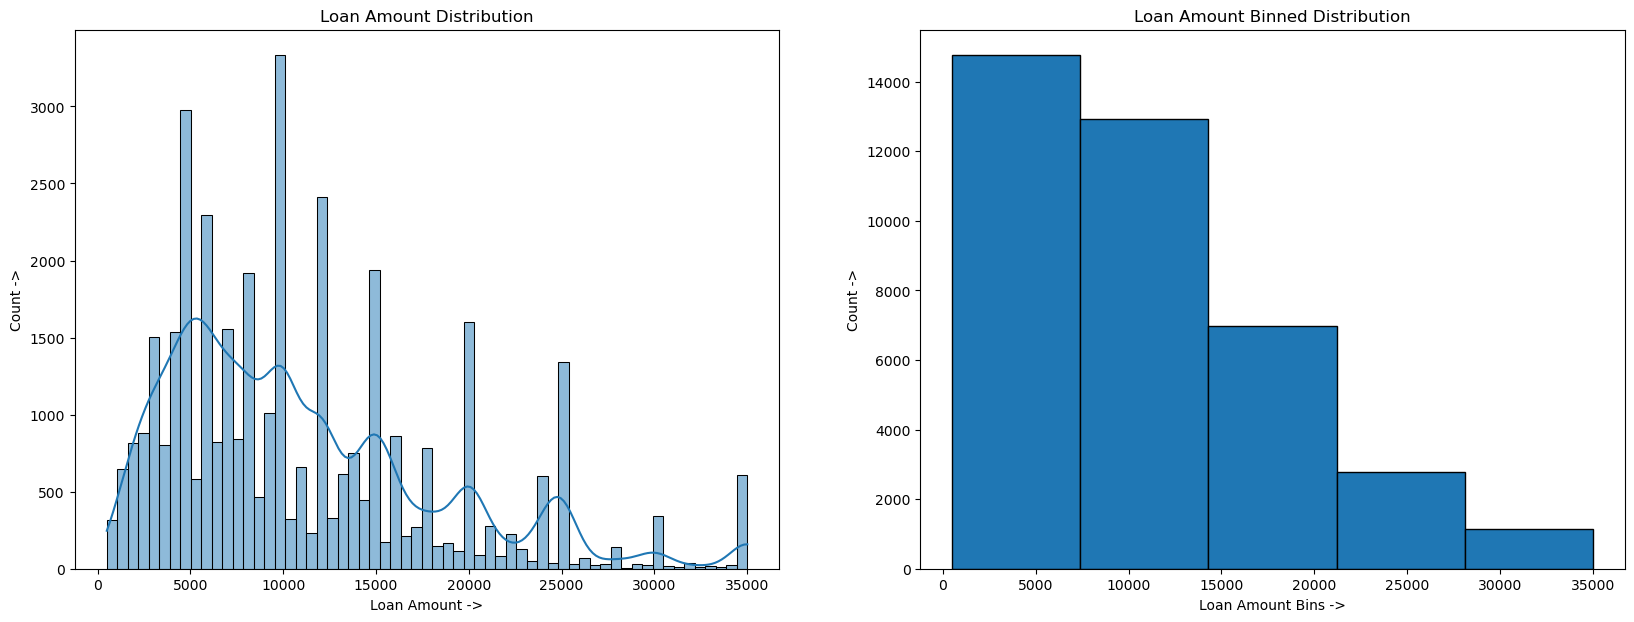

In [74]:
fig, ax = plt.subplots(figsize=(20, 7))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["loan_amnt"],kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel('Loan Amount ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["loan_amnt"], bins=round(lccs_df["loan_amnt"].max()/7000), edgecolor="k")
plt.title("Loan Amount Binned Distribution")
plt.xlabel('Loan Amount Bins ->')
plt.ylabel('Count ->')

plt.show()

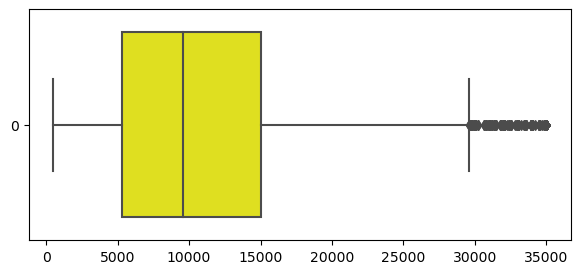

In [75]:
plt.figure(figsize=(7,3))
sns.boxplot(lccs_df["loan_amnt"], color='yellow',orient='h')
plt.show()

In [76]:
loan_amt_df = lccs_df["loan_amnt"].value_counts().reset_index()
loan_amt_df.rename(columns={"index":"loan_amnt","loan_amnt":"count"},inplace=True)
loan_amt_df.sort_values(by="count",ascending=False)

,loan_amnt,count
0,10000,2809
1,12000,2248
2,5000,2028
3,6000,1886
4,15000,1838
...,...,...
740,1475,1
742,7625,1
743,3225,1
744,6675,1


### <font color = green> Observations on univariate analysis on "loan_amnt" column:
> 1. Maximum amount is 35,000 and minimum amount is 500
> 2. Most borrowers borrow amount in the range of 500-7000 followed by 7000-14000

***

>>> ### <font color="blue"> Univariate analysis of int_rate (Loan Interest Rate)

In [77]:
lccs_df["int_rate"].describe()

count    38577.000000
mean        11.932219
std          3.691327
min          5.420000
25%          8.940000
50%         11.710000
75%         14.380000
max         24.400000
Name: int_rate, dtype: float64

In [78]:
loan_int_rate_df = lccs_df.loc[:,["int_rate","int_rate_slabs"]]
loan_int_rate_df["int_rate_slabs"].value_counts()

10.0-12.5    9380
12.5-15.0    8885
7.5-10.0     6946
5.0-7.5      5370
15.0-17.5    5123
17.5-20.0    2103
20.0-22.5     705
22.5-25.0      65
Name: int_rate_slabs, dtype: int64

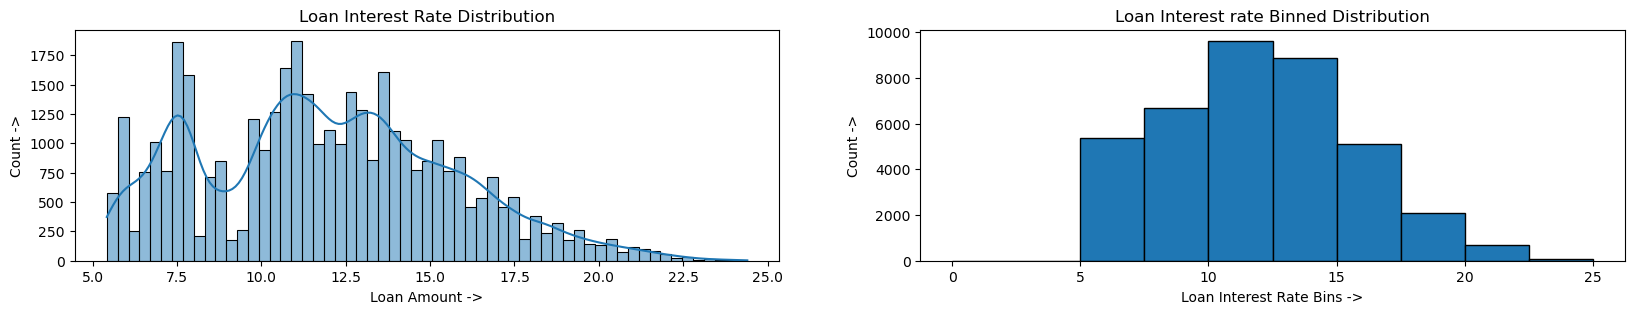

In [79]:
fig, ax = plt.subplots(figsize=(20, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["int_rate"],kde=True)
plt.title("Loan Interest Rate Distribution")
plt.xlabel('Loan Amount ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["int_rate"], bins=[0,2.5,5.0,7.5,10.0,12.5,15.0,17.5,20.0,22.5,25.0], edgecolor="k")
plt.title("Loan Interest rate Binned Distribution")
plt.xlabel('Loan Interest Rate Bins ->')
plt.ylabel('Count ->')

plt.show()

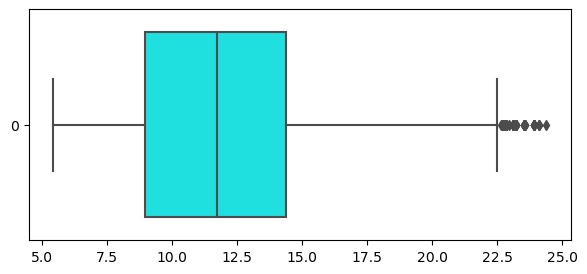

In [80]:
plt.figure(figsize=(7,3))
sns.boxplot(lccs_df["int_rate"], color='cyan',orient='h')
plt.show()

In [81]:
loan_int_rate_df = lccs_df["int_rate"].value_counts().reset_index()
loan_int_rate_df.rename(columns={"index":"int_rate","int_rate":"count"},inplace=True)
loan_int_rate_df.sort_values(by="int_rate",ascending=False)

,int_rate,count
359,24.40,1
334,24.11,3
265,23.91,9
314,23.59,4
296,23.52,6
...,...,...
13,6.03,447
230,6.00,16
26,5.99,347
15,5.79,410


### <font color = green> Observations on univariate analysis on "int_rate" column:
> 1. Maximum interest chanrged is 24.42 and minimum is 5.42
> 2. Maximum borrowers are charged interest between 10-12.5 followed by 12.5-15.0

*******

>>> ### <font color = blue> Univariate analysis of annual_inc (Annual Income of the borrower)

In [82]:
lccs_df["annual_inc"].describe()

count    3.857700e+04
mean     6.877797e+04
std      6.421868e+04
min      4.000000e+03
25%      4.000000e+04
50%      5.886800e+04
75%      8.200000e+04
max      6.000000e+06
Name: annual_inc, dtype: float64

In [83]:
# Since the above stats\istics are in exponential, need to convert to understandable numeric format
annual_inc_df = lccs_df["annual_inc"].describe().reset_index()
annual_inc_df.set_index("index",inplace=True)
annual_inc_df.rename(columns={"index":"stat_type","annual_inc":"stat_value"},inplace=True)
annual_inc_df
print("Maximum annual income: {}".format(annual_inc_df.loc["max","stat_value"]))
print("Minimum annual income: {}".format(annual_inc_df.loc["min","stat_value"]))
print("75th percentile: {}".format(annual_inc_df.loc["75%","stat_value"]))
print("50th percentile: {}".format(annual_inc_df.loc["50%","stat_value"]))
print("25th percentile: {}".format(annual_inc_df.loc["25%","stat_value"]))

Maximum annual income: 6000000.0
Minimum annual income: 4000.0
75th percentile: 82000.0
50th percentile: 58868.0
25th percentile: 40000.0


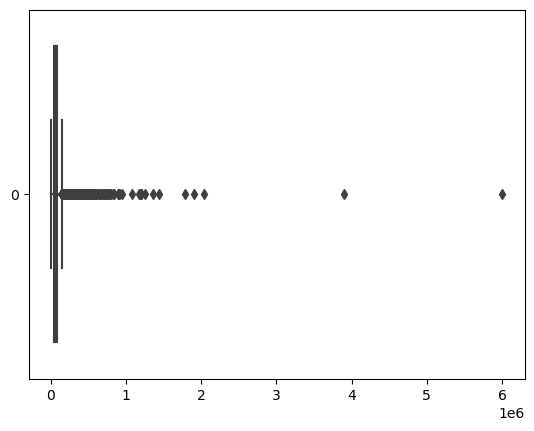

In [84]:
annual_inc_df = lccs_df["annual_inc"].reset_index()
sns.boxplot(lccs_df["annual_inc"],orient="h")
plt.show()

In [85]:
quantile_info = lccs_df["annual_inc"].quantile([0.10, 0.15, 0.20, 0.25, 0.5, 0.75, 0.80, 0.85, 0.90,
                                                0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99])
quantile_info

0.10     30000.00
0.15     34000.00
0.20     37196.16
0.25     40000.00
0.50     58868.00
0.75     82000.00
0.80     90000.00
0.85    100000.00
0.90    115000.00
0.91    120000.00
0.92    122000.00
0.93    127500.00
0.94    134000.00
0.95    140004.00
0.96    150000.00
0.97    165000.00
0.98    187000.00
0.99    234144.00
Name: annual_inc, dtype: float64

For removing the outliers the outer boundary/ threshold is considered to be 95 percentile i.e., 0.95

In [86]:
print(Fore.LIGHTBLUE_EX + "Shape of the dataframe before removing outliers for 'annual_inc': {}"
     .format(lccs_df.shape))

lccs_df = lccs_df[~(lccs_df["annual_inc"] >= lccs_df['annual_inc'].quantile(0.95))]

print(Fore.LIGHTBLUE_EX + "Shape of the dataframe after removing outliers for 'annual_inc': {}"
     .format(lccs_df.shape))

Shape of the dataframe before removing outliers for 'annual_inc': (38577, 27)
Shape of the dataframe after removing outliers for 'annual_inc': (36642, 27)


In [87]:
loan_annual_inc_df = lccs_df["annual_inc"].value_counts().reset_index()
loan_annual_inc_df.rename(columns={"index":"annual_inc","annual_inc":"count"},inplace=True)
loan_annual_inc_df.sort_values(by="count")

loan_annual_inc_df

,annual_inc,count
0,60000.00,1466
1,50000.00,1029
2,40000.00,855
3,45000.00,811
4,30000.00,808
...,...,...
4783,52518.72,1
4784,42204.00,1
4785,47232.00,1
4786,9960.00,1


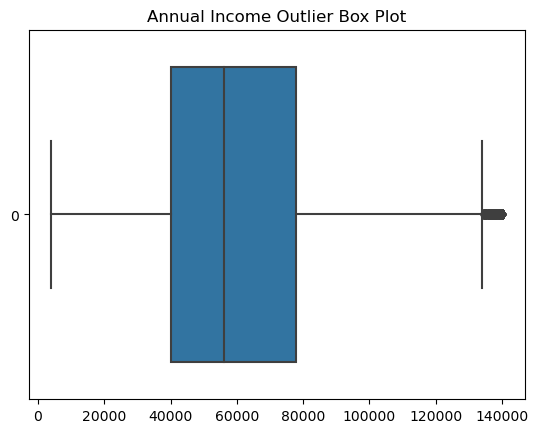

In [88]:
annual_inc_df = lccs_df["annual_inc"].reset_index()
sns.boxplot(lccs_df["annual_inc"],orient="h")

plt.title("Annual Income Outlier Box Plot")

plt.show()

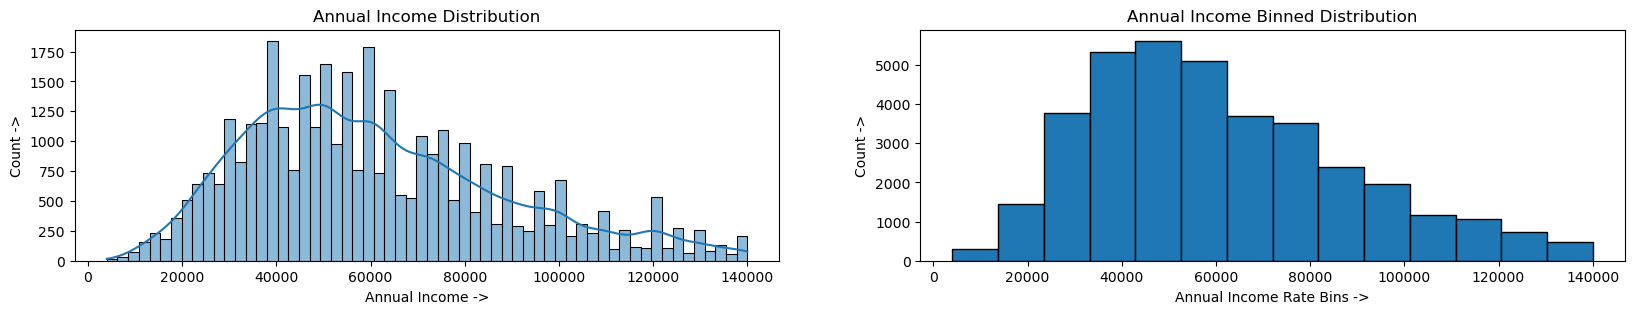

In [89]:
fig, ax = plt.subplots(figsize=(20, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["annual_inc"],kde=True)
plt.title("Annual Income Distribution")
plt.xlabel('Annual Income ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["annual_inc"], bins=14, edgecolor="k")
plt.title("Annual Income Binned Distribution")
plt.xlabel('Annual Income Rate Bins ->')
plt.ylabel('Count ->')

plt.show()

In [90]:
lccs_df["annual_inc"].describe()

count     36642.000000
mean      60829.831120
std       27717.831464
min        4000.000000
25%       40000.000000
50%       56000.000000
75%       77704.050000
max      140000.000000
Name: annual_inc, dtype: float64

### <font color = green> Observations on univariate analysis on "annual_inc" column:
> 1. From the above quantile analysis it is clear that the jump after 0.95 is too pronounced and points to outliers.
> 2. Not cleaning the outliers can greatly influence the analysis in a negative way
> 3. For removing the outliers the outer boundary/ threshold is considered to be 95 percentile i.e., 0.95

***

>>> ### <font color = blue> Univariate analysis of term (Loan Tenure)

In [91]:
# Describe the column to understand the stats
lccs_df["term"].describe()

count    36642.000000
mean        41.847716
std         10.303024
min         36.000000
25%         36.000000
50%         36.000000
75%         36.000000
max         60.000000
Name: term, dtype: float64

In [92]:
loan_term_df = lccs_df["term"].value_counts().reset_index()
loan_term_df.rename(columns={"index":"term","term":"count"},inplace=True)
loan_term_df.set_index("term",inplace=True)
loan_term_df.sort_values(by="count",ascending=False)

,count
term,
36,27714
60,8928


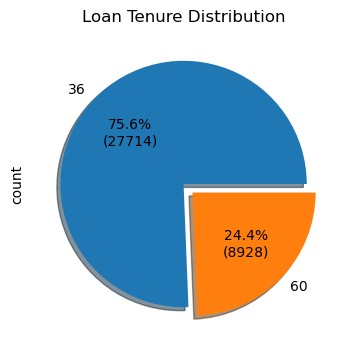

In [93]:
loan_term_df.plot.pie(y='count',legend=False, figsize=(4, 4),autopct= autopct_format(loan_term_df["count"]),
                explode=(0, 0.1), shadow=True, startangle=0)
plt.title("Loan Tenure Distribution")
plt.show()

## <font color = green> Observations on univariate analysis on "term" column:
> 1. Most loans are taken for tenure of 36 Months

***

>>> ### <font color = blue> Univariate analysis of emp_length (Employment tenure of the borrower)

In [94]:
# Describe the column to understand the stats
lccs_df["emp_length"].describe()

count    36642.000000
mean         4.883030
std          3.443242
min          0.000000
25%          2.000000
50%          4.000000
75%          8.000000
max         10.000000
Name: emp_length, dtype: float64

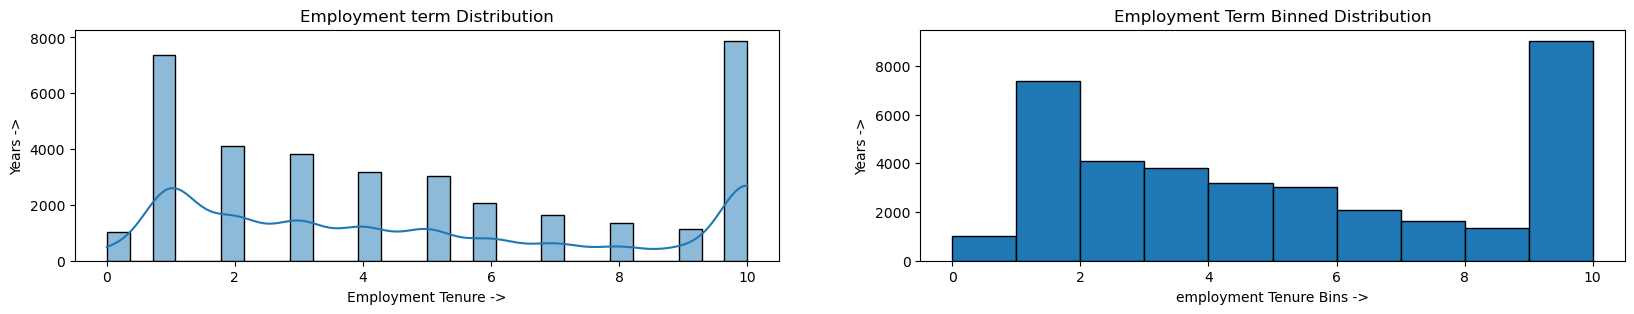

In [95]:
fig, ax = plt.subplots(figsize=(20, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["emp_length"],kde=True)
plt.title("Employment term Distribution")
plt.xlabel('Employment Tenure ->')
plt.ylabel('Years ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["emp_length"], edgecolor="k")
plt.title("Employment Term Binned Distribution")
plt.xlabel('employment Tenure Bins ->')
plt.ylabel('Years ->')

plt.show()

In [96]:
emp_term_df = lccs_df["emp_length"].value_counts().reset_index()
emp_term_df.rename(columns={"index":"emp_tenure","emp_length":"years"},inplace=True)
emp_term_df.sort_values(by="years",ascending=False)

,emp_tenure,years
0,10,7884
1,1,7370
2,2,4101
3,3,3823
4,4,3197
5,5,3044
6,6,2073
7,7,1643
8,8,1341
9,9,1152


## <font color = green> Observations on univariate analysis on "emp_length" column:
> 1. Most of the borrowers in the sample have their employment tenure equal to or greater than 10 years

***

>>> ### <font color = blue> Univariate analysis of dti

In [97]:
# Describe the column to understand the stats
lccs_df["dti"].describe()

count    36642.000000
mean        13.447256
std          6.661561
min          0.000000
25%          8.350000
50%         13.580000
75%         18.717500
max         29.990000
Name: dti, dtype: float64

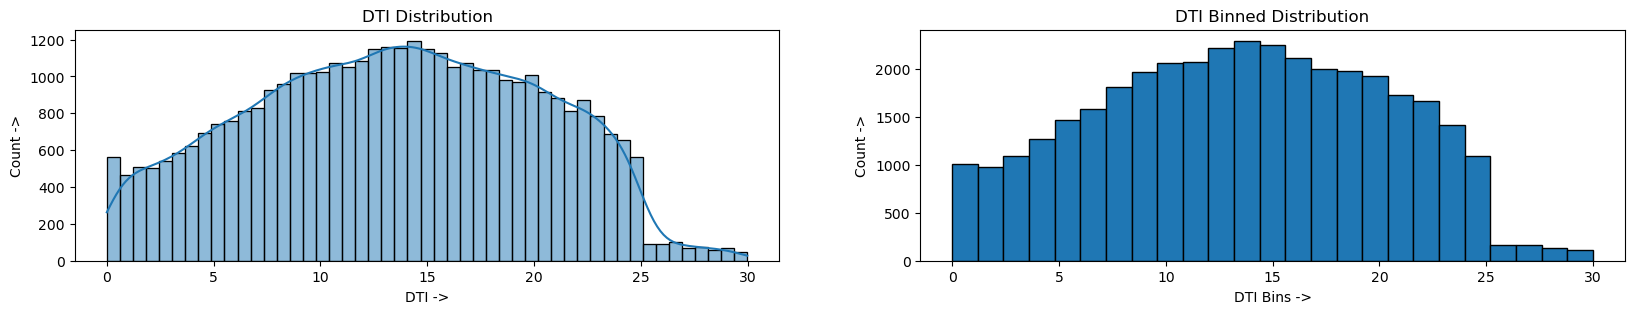

In [98]:
fig, ax = plt.subplots(figsize=(20, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["dti"],kde=True)
plt.title("DTI Distribution")
plt.xlabel('DTI ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["dti"], edgecolor="k",bins=25)
plt.title("DTI Binned Distribution")
plt.xlabel('DTI Bins ->')
plt.ylabel('Count ->')

plt.show()

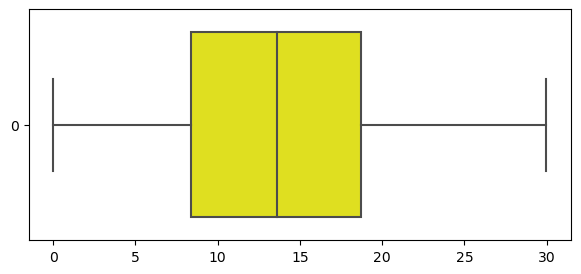

In [99]:
plt.figure(figsize=(7,3))
sns.boxplot(lccs_df["dti"], color='yellow',orient='h')
plt.show()

In [100]:
loan_dti_df = lccs_df["dti"].value_counts().reset_index()
loan_dti_df.rename(columns={"index":"dti","dti":"count"},inplace=True)
loan_dti_df.sort_values(by="count",ascending=False)

,dti,count
0,0.00,170
1,18.00,44
2,12.00,42
3,19.20,39
4,13.20,38
...,...,...
2727,28.08,1
2728,25.16,1
2729,27.46,1
2730,29.08,1


In [101]:
lccs_df["dti_slabs"].value_counts()

10-15    9165
15-20    8524
5-10     7264
20-25    6458
0-5      4447
25-30     614
Name: dti_slabs, dtype: int64

## <font color = green> Observations on univariate analysis on "dti" column:
> 1. Maximum borrowers have their "dti" in the range 10-15 followed by in the range 15-20

***

>>> ### <font color = blue> Univariate analysis of open_acc

In [102]:
# Describe the column to understand the stats
lccs_df["open_acc"].describe()

count    36642.000000
mean         9.166366
std          4.352874
min          2.000000
25%          6.000000
50%          8.000000
75%         12.000000
max         44.000000
Name: open_acc, dtype: float64

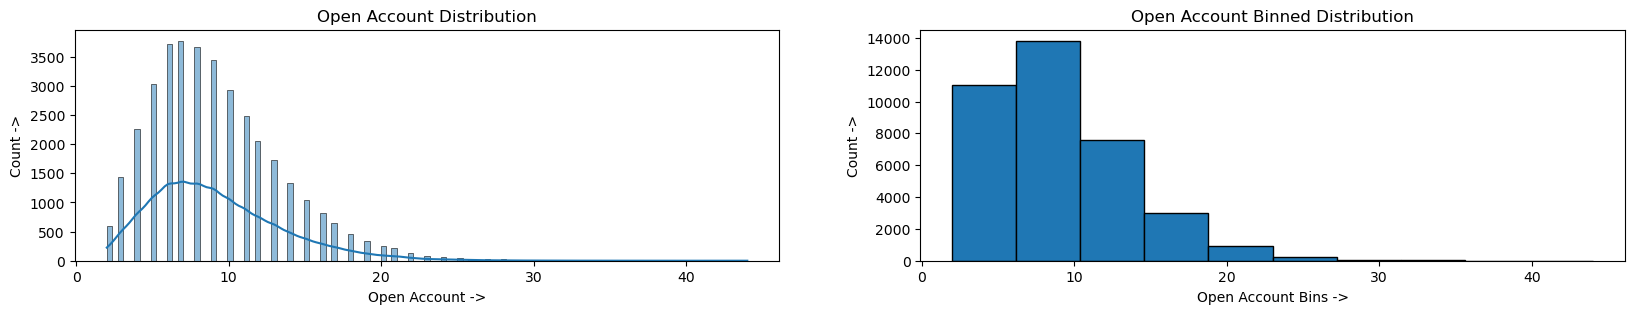

In [103]:
fig, ax = plt.subplots(figsize=(20, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["open_acc"],kde=True)
plt.title("Open Account Distribution")
plt.xlabel('Open Account ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["open_acc"], edgecolor="k")
plt.title("Open Account Binned Distribution")
plt.xlabel('Open Account Bins ->')
plt.ylabel('Count ->')

plt.show()

In [104]:
loan_open_acc_df = lccs_df["open_acc"].value_counts().reset_index()
loan_open_acc_df.rename(columns={"index":"open_acc","open_acc":"count"},inplace=True)
loan_open_acc_df.sort_values(by="count",ascending=False)

,open_acc,count
0,7,3775
1,6,3712
2,8,3667
3,9,3447
4,5,3026
5,10,2929
6,11,2488
7,4,2253
8,12,2046
9,13,1720


## <font color = green> Observations on univariate analysis on "open_acc" column:
> 1. Maximum borrowers have their open credit lines between 5-11

***

>>> ### <font color = blue> Univariate analysis of total_acc

In [105]:
# Describe the column to understand the stats
lccs_df["total_acc"].describe()

count    36642.000000
mean        21.637656
std         11.231134
min          2.000000
25%         13.000000
50%         20.000000
75%         28.000000
max         90.000000
Name: total_acc, dtype: float64

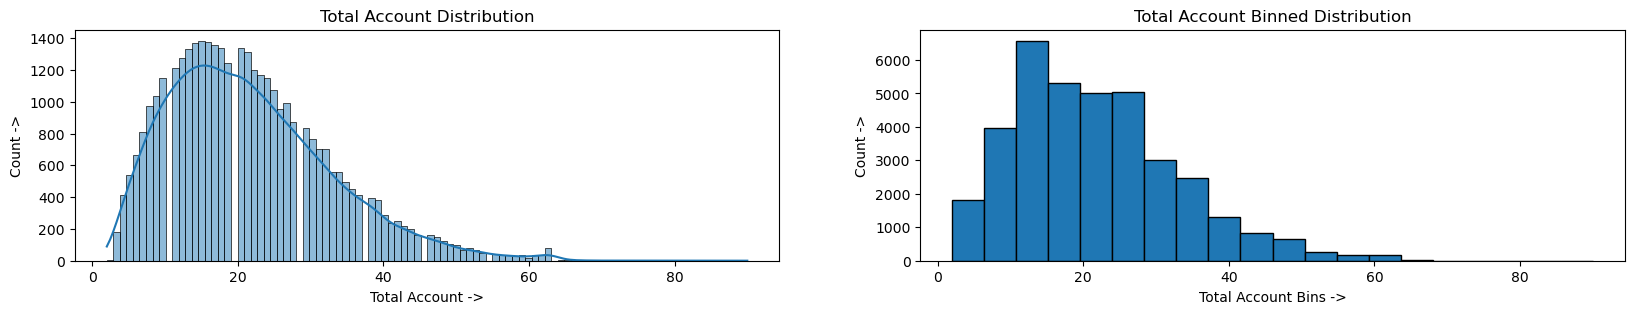

In [106]:
fig, ax = plt.subplots(figsize=(20, 3))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["total_acc"],kde=True)
plt.title("Total Account Distribution")
plt.xlabel('Total Account ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["total_acc"], edgecolor="k",bins=20)
plt.title("Total Account Binned Distribution")
plt.xlabel('Total Account Bins ->')
plt.ylabel('Count ->')

plt.show()

In [107]:
loan_total_acc_df = lccs_df["total_acc"].value_counts().reset_index()
loan_total_acc_df.rename(columns={"index":"total_acc","total_acc":"count"},inplace=True)
loan_total_acc_df.sort_values(by="count",ascending=False)

,total_acc,count
0,15,1384
1,16,1377
2,14,1371
3,17,1359
4,20,1340
...,...,...
70,73,1
69,70,1
68,68,1
67,75,1


## <font color = green> Observations on univariate analysis on "total_acc" column:
> 1. Maximum borrowers have total number of credit lines between 10-15

***

>>> ### <font color = blue> Univariate analysis of 'delinq_2yrs' column

In [108]:
loan_delinq_2yrs_df = lccs_df["delinq_2yrs"].value_counts().reset_index()
loan_delinq_2yrs_df.set_index("index",inplace=True)
loan_delinq_2yrs_df.rename(columns={"delinq_2yrs":"delinq_2yrs_total"},inplace=True)
loan_delinq_2yrs_df.index.rename("delinq_2yrs_value",inplace=True)
loan_delinq_2yrs_df["delinq_2yrs_charged_off"] = lccs_df[lccs_df["loan_status"] == "Charged Off"].loc[:,"delinq_2yrs"].value_counts()

# Drop rows with even 1 NaN value
loan_delinq_2yrs_df.dropna(inplace=True) 

loan_delinq_2yrs_df["perc_charged_off"] = round((loan_delinq_2yrs_df["delinq_2yrs_charged_off"]/loan_delinq_2yrs_df["delinq_2yrs_total"])*100)
loan_delinq_2yrs_df

,delinq_2yrs_total,delinq_2yrs_charged_off,perc_charged_off
delinq_2yrs_value,,,
0,32700,4757.0,15.0
1,3032,489.0,16.0
2,615,117.0,19.0
3,202,35.0,17.0
4,57,13.0,23.0
5,18,2.0,11.0
6,10,1.0,10.0
7,4,1.0,25.0
8,2,1.0,50.0


## <font color = green> Observations on univariate analysis on "delinq_2yrs" column:
> 1. Maximum borrowers have 0 deling_2yrs value and unfortunately this same group has the maximum defaulters too
> 2. Since even with 0 delinq records the borrowers are defaulting, this column will not help in our analysis.

***

### <center> <font color = purple> UNIVARIATE Analysis - Categorical columns

>>> ### <font color = blue> Univariate analysis of loan_status

In [109]:
loan_status_df = lccs_df["loan_status"].value_counts().reset_index()
loan_status_df.columns = ["loan_status","count"]
loan_status_df.set_index("loan_status",inplace=True)
display(loan_status_df)

,count
loan_status,
Fully Paid,31226
Charged Off,5416


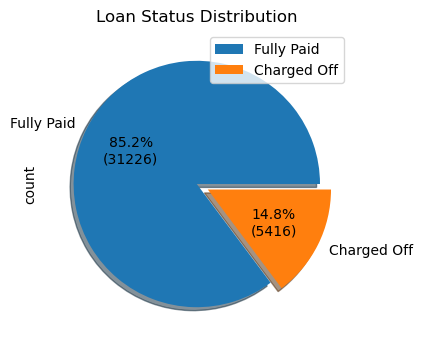

In [110]:
# sns.countplot(x = "loan_status", data = lccs_df)

loan_status_df.plot.pie(y='count',legend=False, figsize=(5, 4), explode=(0, 0.1),shadow=True, startangle=0,
                       autopct= autopct_format(loan_status_df["count"]))
plt.title("Loan Status Distribution")
plt.legend(loc ="upper right")
plt.show()

In [111]:
loan_status_df["percentage"] = loan_status_df["count"].apply(lambda x: (x/loan_status_df["count"].sum())*100)
loan_status_df

,count,percentage
loan_status,,
Fully Paid,31226,85.219147
Charged Off,5416,14.780853


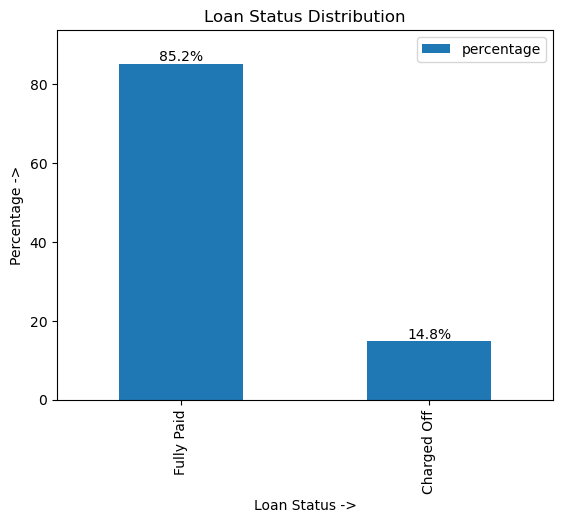

In [112]:
ax = loan_status_df.loc[:,["percentage"]].plot.bar()

ax.bar_label(ax.containers[0],fmt='%.1f%%', label_type='edge')
    
ax.margins(y=0.1)
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status ->")
plt.ylabel("Percentage ->")
plt.show()

## <font color = green> Observations on univariate analysis on "loan_status" column:
> 1. Out of the total loan, around 15% loans are defaulted
> "loan_status" is the driveing variable for our analysis.
> The defaulting percentage is currently 15%. Any parameter which helps us in reducing this percentage will need to be identified for meeting the objective.

***

>>> ### <font color = blue> Univariate analysis of grade

In [113]:
loan_grade_df = lccs_df["grade"].value_counts().reset_index()
loan_grade_df.columns = ["grade","count"]
loan_grade_df.set_index("grade",inplace=True)
loan_grade_df["percentage"] = (loan_grade_df["count"]/(loan_grade_df["count"].sum())*100)
loan_grade_df.sort_index()
loan_grade_df

,count,percentage
grade,,
B,11096,30.282190
A,9643,26.316795
C,7477,20.405546
D,4834,13.192511
E,2445,6.672671
F,886,2.417990
G,261,0.712297


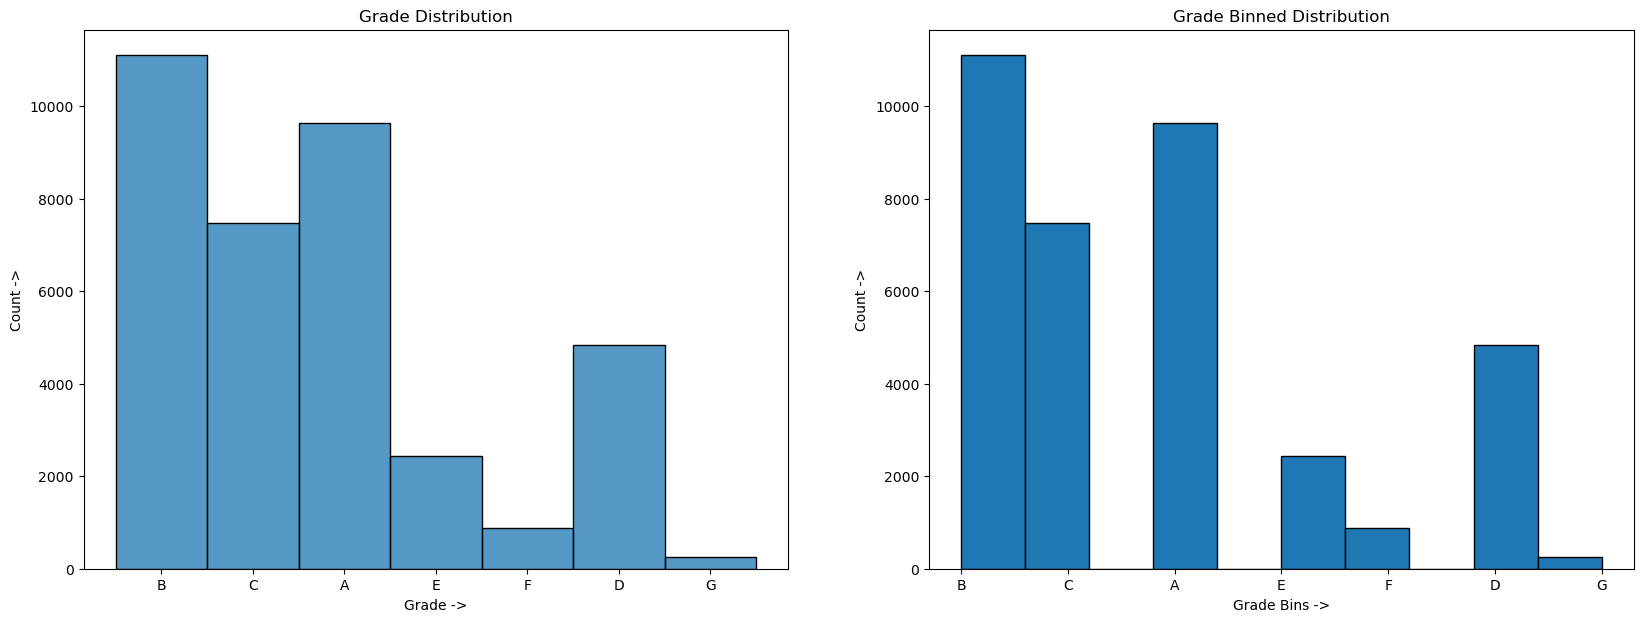

In [114]:
fig, ax = plt.subplots(figsize=(20, 7))

plt.subplot(1, 2, 1)
sns.histplot(data=lccs_df,x=lccs_df["grade"])
plt.title("Grade Distribution")
plt.xlabel('Grade ->')
plt.ylabel('Count ->')

plt.subplot(1, 2, 2)
plt.hist(lccs_df["grade"], edgecolor="k")
plt.title("Grade Binned Distribution")
plt.xlabel('Grade Bins ->')
plt.ylabel('Count ->')

plt.show()

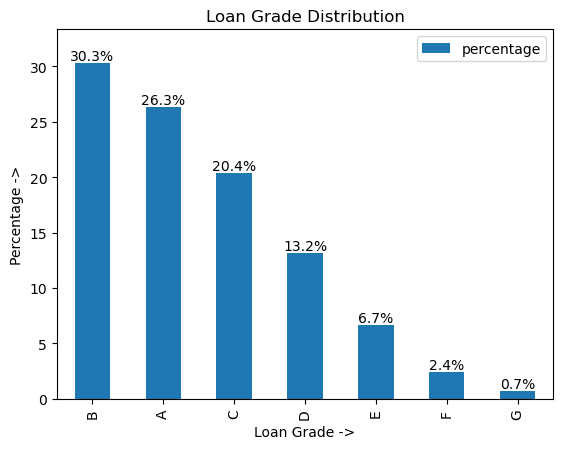

In [115]:
ax = loan_grade_df.loc[:,["percentage"]].plot.bar()

ax.bar_label(ax.containers[0],fmt='%.1f%%', label_type='edge')
    
ax.margins(y=0.1)
plt.title("Loan Grade Distribution")
plt.xlabel("Loan Grade ->")
plt.ylabel("Percentage ->")
plt.show()

### <font color = green> Observations on univariate analysis on "grade" column:
> 1. Loans are classified into 7 different grades
> 2. Maximum loans belong to grade-B closely followed by grade-A

***

>>> ### <font color = blue> Univariate analysis of "sub_grade"

In [116]:
loan_sub_grade_df = lccs_df["sub_grade"].value_counts().reset_index()
loan_sub_grade_df.columns = ["sub_grade","count"]
loan_sub_grade_df.set_index("sub_grade",inplace=True)
# loan_sub_grade_df.sort_values(by="sub_grade")
loan_sub_grade_df

,count
sub_grade,
A4,2748
B3,2654
A5,2599
B5,2492
B4,2333
C1,1961
B2,1899
C2,1847
A3,1748


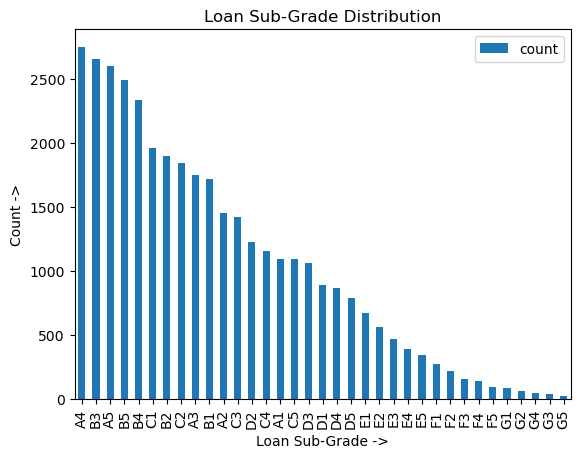

In [117]:
loan_sub_grade_df.plot.bar()
plt.title("Loan Sub-Grade Distribution")
plt.xlabel("Loan Sub-Grade ->")
plt.ylabel("Count ->")
plt.show()

### <font color = green> Observations on univariate analysis on "sub_grade" column:
> 1. Maximum borrowers lie in the sub-grades with prefix A,B or C

***

>>> ### <font color = blue> Univariate analysis of home_ownership

In [118]:
loan_home_ownership_df = lccs_df["home_ownership"].value_counts().reset_index()
loan_home_ownership_df.columns = ["home_ownership","count"]
loan_home_ownership_df.set_index("home_ownership",inplace=True)
loan_home_ownership_df["percentage"] = loan_home_ownership_df["count"].apply(lambda x: 
                                                                             (x/loan_home_ownership_df["count"]
                                                                              .sum())*100)
loan_home_ownership_df

,count,percentage
home_ownership,,
RENT,18029,49.203100
MORTGAGE,15666,42.754216
OWN,2852,7.783418
OTHER,92,0.251078
NONE,3,0.008187


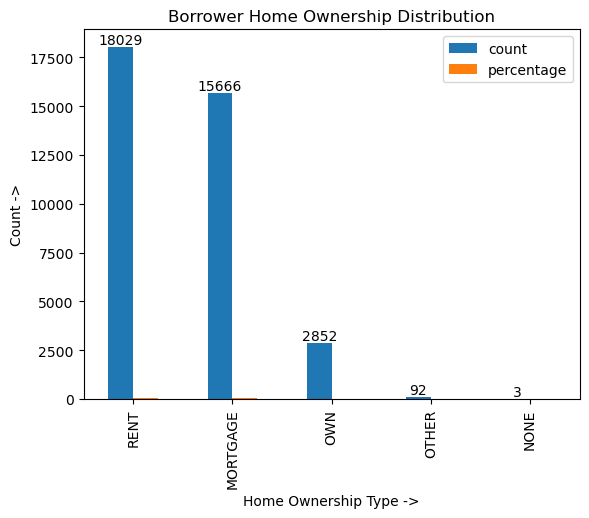

In [119]:
chart = loan_home_ownership_df.plot.bar()
plt.bar_label(chart.containers[0],label_type='edge')
plt.title("Borrower Home Ownership Distribution")
plt.xlabel("Home Ownership Type ->")
plt.ylabel("Count ->")
plt.show()

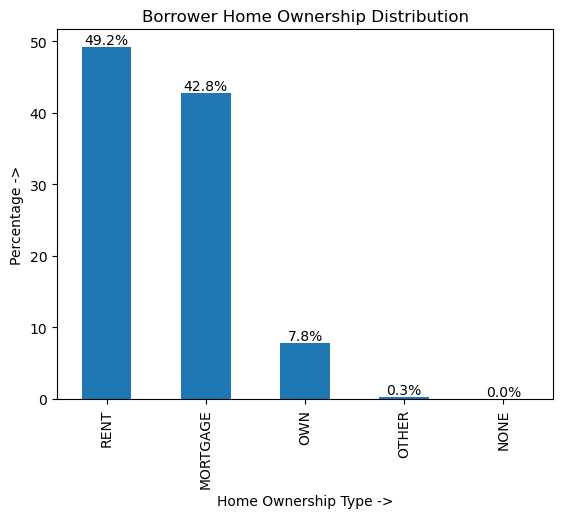

In [120]:
chart = loan_home_ownership_df.loc[:,"percentage"].plot.bar()
plt.bar_label(chart.containers[0],label_type='edge',fmt='%.1f%%')
plt.title("Borrower Home Ownership Distribution")
plt.xlabel("Home Ownership Type ->")
plt.ylabel("Percentage ->")
plt.show()

### <font color = green> Observations on univariate analysis on "home_ownership" column:
> 1. Most borrowers do not have their own home
> Maximum borrowers are staying in a rented place or in mortgaged property

***

>>> ### <font color = blue> Univariate analysis of verification_status

In [121]:
loan_verification_status_df = lccs_df["verification_status"].value_counts().reset_index()
loan_verification_status_df.columns = ["verification_status","count"]
loan_verification_status_df.set_index("verification_status",inplace=True)
loan_verification_status_df["percentage"] = loan_verification_status_df["count"].apply(lambda x: (x/loan_verification_status_df["count"].sum())*100)
loan_verification_status_df

,count,percentage
verification_status,,
Not Verified,16278,44.424431
Verified,11214,30.604225
Source Verified,9150,24.971344


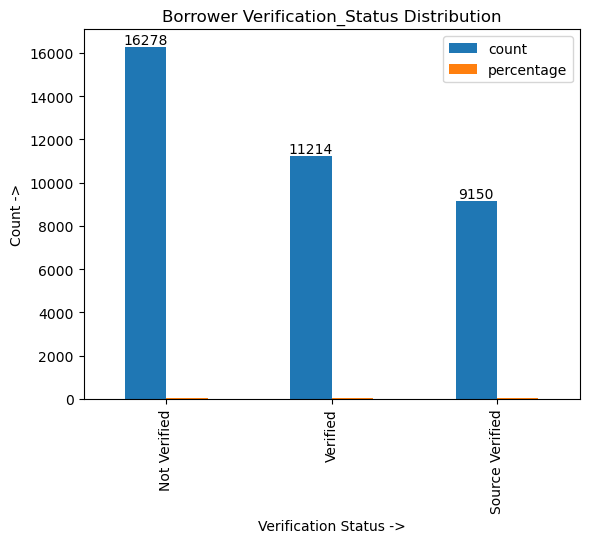

In [122]:
chart = loan_verification_status_df.plot.bar()
plt.bar_label(chart.containers[0],label_type='edge')
plt.title("Borrower Verification_Status Distribution")
plt.xlabel("Verification Status ->")
plt.ylabel("Count ->")
plt.show()

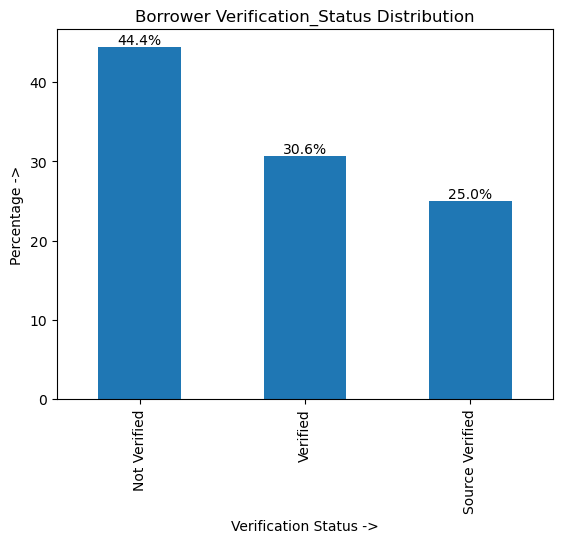

In [123]:
chart = loan_verification_status_df.loc[:,"percentage"].plot.bar()
plt.bar_label(chart.containers[0],label_type='edge',fmt="%.1f%%")
plt.title("Borrower Verification_Status Distribution")
plt.xlabel("Verification Status ->")
plt.ylabel("Percentage ->")
plt.show()

### <font color = green> Observations on univariate analysis on "verification_status" column:
> 1. Maximum borrowers are not verified before being granted loans

***

>>> ### <font color = blue> Univariate analysis of purpose

In [124]:
loan_purpose_df = lccs_df["purpose"].value_counts().reset_index()
loan_purpose_df.columns = ["purpose","count"]
loan_purpose_df.set_index("purpose",inplace=True)
loan_purpose_df["percentage"]= loan_purpose_df["count"].apply(lambda x: (x/loan_purpose_df["count"].sum())*100)
loan_purpose_df

,count,percentage
purpose,,
debt_consolidation,17301,47.216309
credit_card,4782,13.050598
other,3696,10.086786
home_improvement,2555,6.972873
major_purchase,2045,5.581027
small_business,1623,4.429343
car,1448,3.951749
wedding,892,2.434365
medical,640,1.746630


<Figure size 600x600 with 0 Axes>

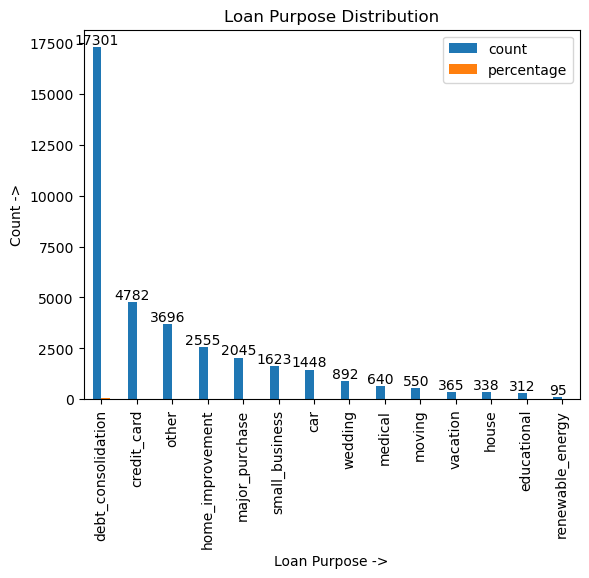

In [125]:
plt.figure(figsize=(6,6))
chart = loan_purpose_df.plot.bar()
plt.bar_label(chart.containers[0])
plt.title("Loan Purpose Distribution")
plt.xlabel("Loan Purpose ->")
plt.ylabel("Count ->")
plt.show()

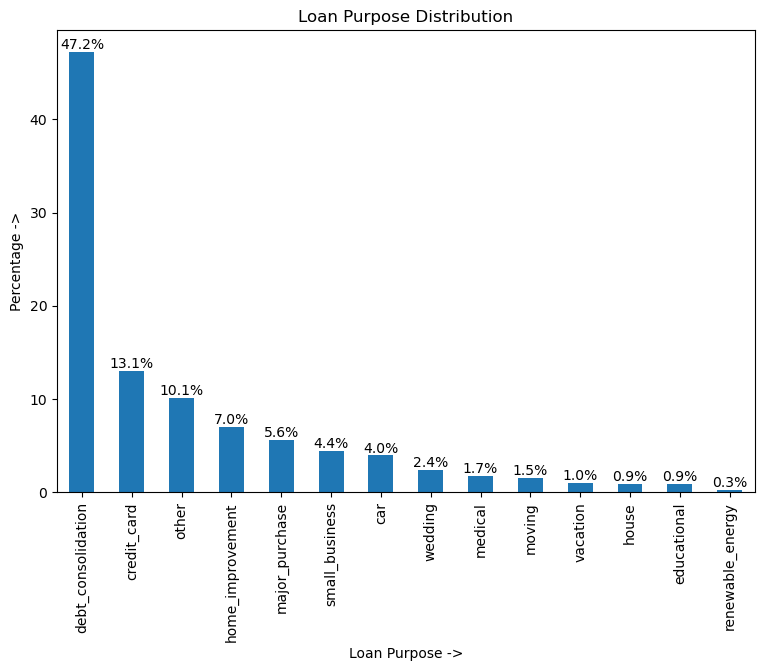

In [126]:
plt.figure(figsize=(9,6))
chart = loan_purpose_df.loc[:,"percentage"].plot.bar()
plt.bar_label(chart.containers[0],fmt="%.1f%%")
plt.title("Loan Purpose Distribution")
plt.xlabel("Loan Purpose ->")
plt.ylabel("Percentage ->")
plt.show()

## <font color = green> Observations on univariate analysis on "purpose" column:
> 1. Most borrowers are applying for loan to clear off their existing loans/debts/credit as is apparent by maximum borrowers purpsoe being debt consolidation  and credit card

### <center> <font color = purple> BI-VARIATE Analysis

#### The column "loan_status" is the driving variable based on which the analysis is to be carried out. As per the sample, about 15% of the loans are being defaulted/written-off now. Any parameter that helps bring this percentage down is the one which would help us meet the objectives of this case study.

>>> ### <font color = blue> Bivariate analysis: "loan_amnt" vs "loan_status"

75% value for Loan amount (Fully Paid): 14400.0
75% value for Loan amount (Charged Off): 16000.0


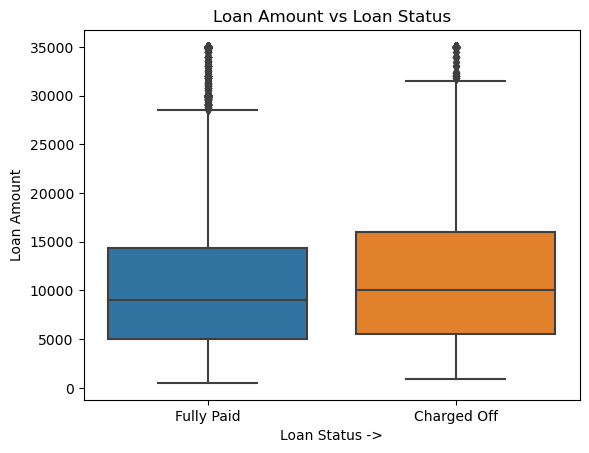

In [127]:
print("75% value for Loan amount (Fully Paid): {}"
      .format(lccs_df["loan_amnt"].loc[lccs_df["loan_status"] == "Fully Paid"].quantile(0.75)))

print("75% value for Loan amount (Charged Off): {}"
      .format(lccs_df["loan_amnt"].loc[lccs_df["loan_status"] == "Charged Off"].quantile(0.75)))


sns.boxplot(x="loan_status",data=lccs_df,y="loan_amnt")
plt.title("Loan Amount vs Loan Status")
plt.xlabel("Loan Status ->")
plt.ylabel("Loan Amount")
plt.show()

##### There is too much noise in the sample at the higher end. These Outliers in "loan_amnt" found and need to be handled for better analysis

In [128]:
lccs_df["loan_amnt"].describe()

count    36642.000000
mean     10681.045658
std       7047.619569
min        500.000000
25%       5000.000000
50%       9250.000000
75%      15000.000000
max      35000.000000
Name: loan_amnt, dtype: float64

75% value for Loan amount less than 15000 (Fully Paid): 10181.25
75% value for Loan amount less than 15000 (Charged Off): 10712.5


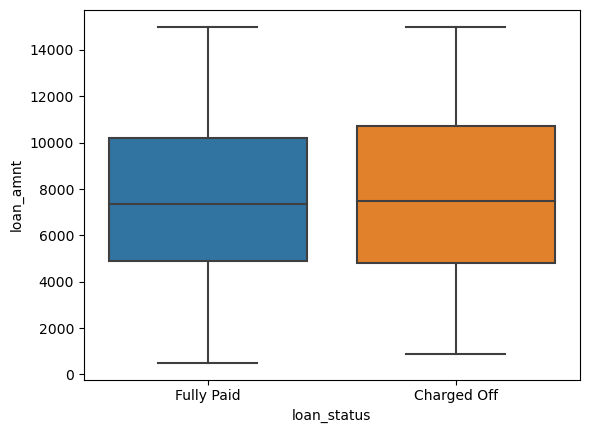

In [129]:
# Let's consider data where in "loan_amnt" is less than or equal to 75% i.e., 15,000
loan_amnt_less_15000 = lccs_df.loc[lccs_df["loan_amnt"] <= 15000]
loan_amnt_less_15000.shape

print("75% value for Loan amount less than 15000 (Fully Paid): {}"
      .format(loan_amnt_less_15000["loan_amnt"].loc[loan_amnt_less_15000["loan_status"] == "Fully Paid"].quantile(0.75)))

print("75% value for Loan amount less than 15000 (Charged Off): {}"
      .format(loan_amnt_less_15000["loan_amnt"].loc[loan_amnt_less_15000["loan_status"] == "Charged Off"].quantile(0.75)))

sns.boxplot(x="loan_status",data=loan_amnt_less_15000,y="loan_amnt")
plt.show()

75% value for Loan amount greater than 15000 (Fully Paid): 24000.0
75% value for Loan amount greater than 15000 (Charged Off): 25000.0


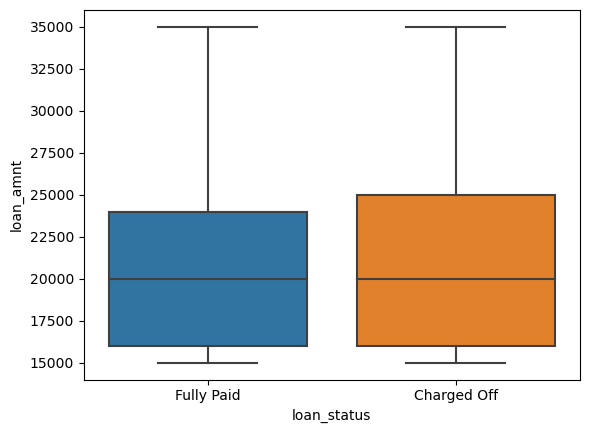

In [130]:
# Let's consider data where in "loan_amnt" is less than or equal to 75% i.e., 15,000
loan_amnt_greater_15000 = lccs_df.loc[lccs_df["loan_amnt"] >= 15000]
loan_amnt_greater_15000.shape

print("75% value for Loan amount greater than 15000 (Fully Paid): {}"
      .format(loan_amnt_greater_15000["loan_amnt"].loc[loan_amnt_greater_15000["loan_status"] == "Fully Paid"].quantile(0.75)))

print("75% value for Loan amount greater than 15000 (Charged Off): {}"
      .format(loan_amnt_greater_15000["loan_amnt"].loc[loan_amnt_greater_15000["loan_status"] == "Charged Off"].quantile(0.75)))

sns.boxplot(x="loan_status",data=loan_amnt_greater_15000,y="loan_amnt")
plt.show()

In [131]:
loan_status_vs_amnt = lccs_df.loc[:,["loan_amnt","loan_status","loan_amnt_slabs"]]

loan_status_vs_amnt["loan_amnt_slabs"]. value_counts()

0-7000         14049
7000-14000     12810
14000-21000     6558
21000-28000     2368
28000-35000      857
Name: loan_amnt_slabs, dtype: int64

In [132]:
# Fetch only charged off loans
loan_status_vs_amnt = loan_status_vs_amnt[loan_status_vs_amnt["loan_status"] == "Charged Off"]
loan_status_vs_amnt["loan_amnt_slabs"]. value_counts()

0-7000         1864
7000-14000     1742
14000-21000    1109
21000-28000     480
28000-35000     221
Name: loan_amnt_slabs, dtype: int64

In [133]:
loan_status_vs_amnt_df = pd.crosstab(lccs_df["loan_amnt_slabs"], lccs_df["loan_status"])
loan_status_vs_amnt_df["Total"] = loan_status_vs_amnt_df["Charged Off"] + loan_status_vs_amnt_df["Fully Paid"]
loan_status_vs_amnt_df["Perc_Charged_Off"] = round(((loan_status_vs_amnt_df["Charged Off"])
                                                       /(loan_status_vs_amnt_df["Total"])*100),2)
loan_status_vs_amnt_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
loan_amnt_slabs,,,,
0-7000,1864,12185,14049,13.27
7000-14000,1742,11068,12810,13.60
14000-21000,1109,5449,6558,16.91
21000-28000,480,1888,2368,20.27
28000-35000,221,636,857,25.79


In [134]:
loan_status_vs_amnt_df.reset_index(inplace=True)

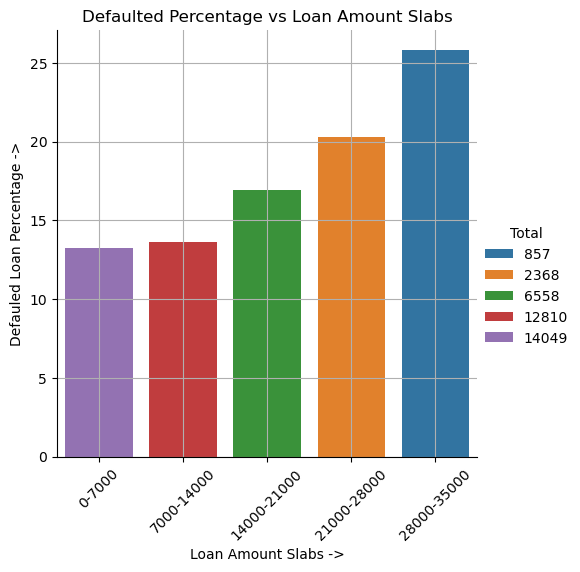

In [135]:
sns.catplot(x='loan_amnt_slabs', y='Perc_Charged_Off', hue='Total', data=loan_status_vs_amnt_df, kind='bar',
            legend=True, dodge=False)
plt.xticks(rotation=45)
plt.title("Defaulted Percentage vs Loan Amount Slabs")
plt.xlabel("Loan Amount Slabs ->")
plt.ylabel("Defauled Loan Percentage ->")
plt.grid()
plt.show()

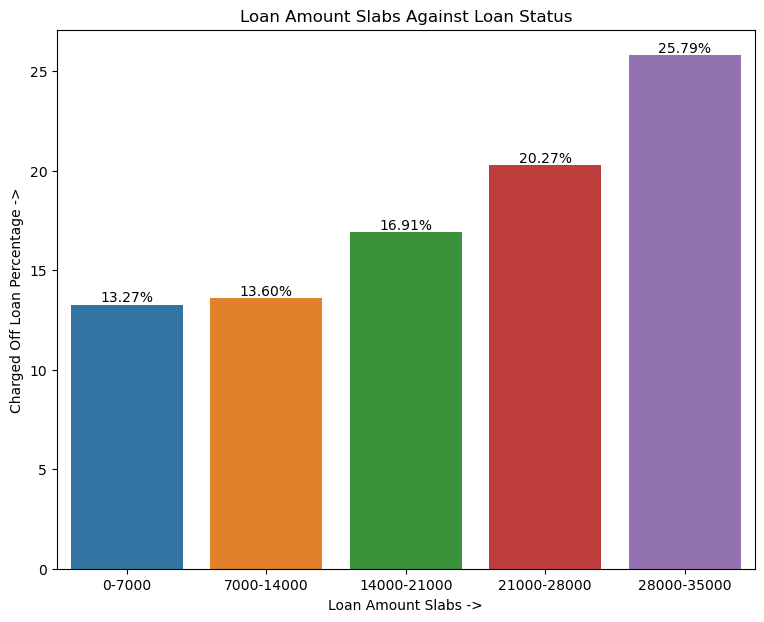

In [136]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=loan_status_vs_amnt_df,x="loan_amnt_slabs",y="Perc_Charged_Off")

plt.bar_label(ax.containers[0],fmt='%.2f%%',label_type="edge")
plt.title("Loan Amount Slabs Against Loan Status")
plt.xlabel("Loan Amount Slabs ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "loan_amnt" vs "loan_status"
> 1. Analysis exempted loan_status of type "Current"
> 2. Analysis of the complate dataframe lead to the thinking that higher the amount, higher the chance of
    it being written-off. This was can be checked by higher 75% value for the two type of "loan_status"
> 3. With the 75% value of 15,000 being taken for outlier handling, it was confirmed again that higher amount
    leads to higher rate of write-offs.
> 4. Analysis was conducted on loan amount greater and also lesser then 75 percentile
> Higher loan amounts leads to higher default rates

***

>>> ### <font color = blue> Bivariate analysis: "term" vs "loan_status"

In [137]:
term_vs_loan_status_df = lccs_df.loc[:,["loan_status","term"]]

term_vs_loan_status_df.groupby("loan_status").value_counts()

loan_status  term
Charged Off  36       3113
             60       2303
Fully Paid   36      24601
             60       6625
dtype: int64

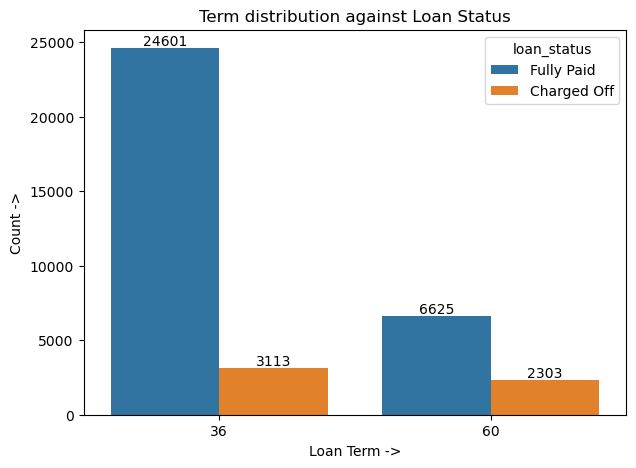

In [138]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=lccs_df,x="term",hue="loan_status")
plt.bar_label(ax.containers[0])
plt.title("Term distribution against Loan Status")
plt.xlabel("Loan Term ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.show()

## <font color = green> Observations on bivariate analysis: "term" vs "loan_status"
> 1. Above results for "loan_status" vs "term" point to the conclusion that higher tenured loans
    have a greater probability of being written-off

>>> ### <font color = blue> Bivariate analysis: "term" vs "loan_amnt"

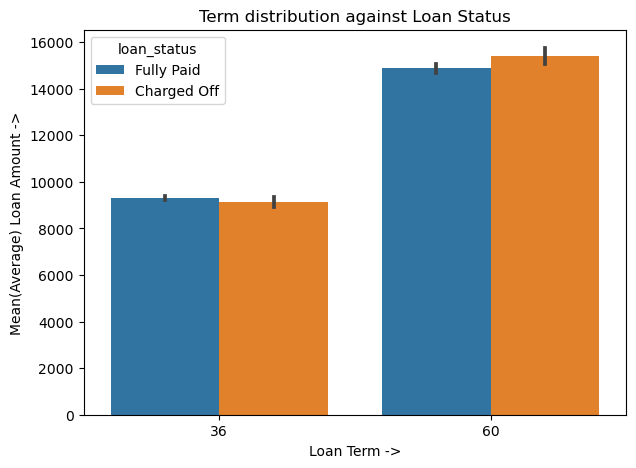

In [139]:
plt.figure(figsize=(7,5))
ax = sns.barplot(data=lccs_df,x="term",y="loan_amnt",hue="loan_status",estimator=np.mean)
plt.title("Term distribution against Loan Status")
plt.xlabel("Loan Term ->")
plt.ylabel("Mean(Average) Loan Amount ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "term" vs "loan_amnt"
> 1. Above results for "loan_amnt" vs "term" point to the conclusion that the average loan amount across loan statuses for both terms remains the same
> 2. Loan amount disbursed for term 60 Months is higher compared to that of 36 months

***

>>> ### <font color = blue> Bivariate analysis: "term" vs "int_rate"

In [140]:
loan_term_vs_int_rate_df = lccs_df[["int_rate","term"]].reset_index()

loan_term_vs_int_rate_36_df = loan_term_vs_int_rate_df.loc[loan_term_vs_int_rate_df["term"] == 36]
print(Fore.GREEN+"25th, median and 75th percentile values for interest rate for 36 months: {}, {}, {}"
     .format(loan_term_vs_int_rate_36_df["int_rate"].quantile(0.25),
             loan_term_vs_int_rate_36_df["int_rate"].quantile(0.50),
             loan_term_vs_int_rate_36_df["int_rate"].quantile(0.75)))

loan_term_vs_int_rate_60_df = loan_term_vs_int_rate_df.loc[loan_term_vs_int_rate_df["term"] == 60]
print(Fore.GREEN+"25th, median and 75th percentile values for interest rate for 60 months: {}, {}, {}"
     .format(loan_term_vs_int_rate_60_df["int_rate"].quantile(0.25),
             loan_term_vs_int_rate_60_df["int_rate"].quantile(0.50),
             loan_term_vs_int_rate_60_df["int_rate"].quantile(0.75)))

25th, median and 75th percentile values for interest rate for 36 months: 7.9, 10.99, 13.47
25th, median and 75th percentile values for interest rate for 60 months: 11.86, 14.79, 17.27


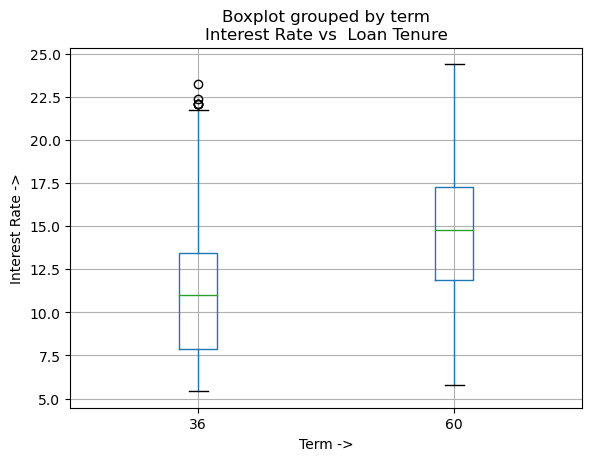

In [141]:
lccs_df.boxplot(column="int_rate", by="term")
plt.title("Interest Rate vs  Loan Tenure")
plt.xlabel("Term ->")
plt.ylabel("Interest Rate ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "term" vs "int_rate"
> 1. Generally the interest rates for 60 months tenure loans are higher

>>> ### <font color = blue> Bivariate analysis: "dti" vs "loan_status"

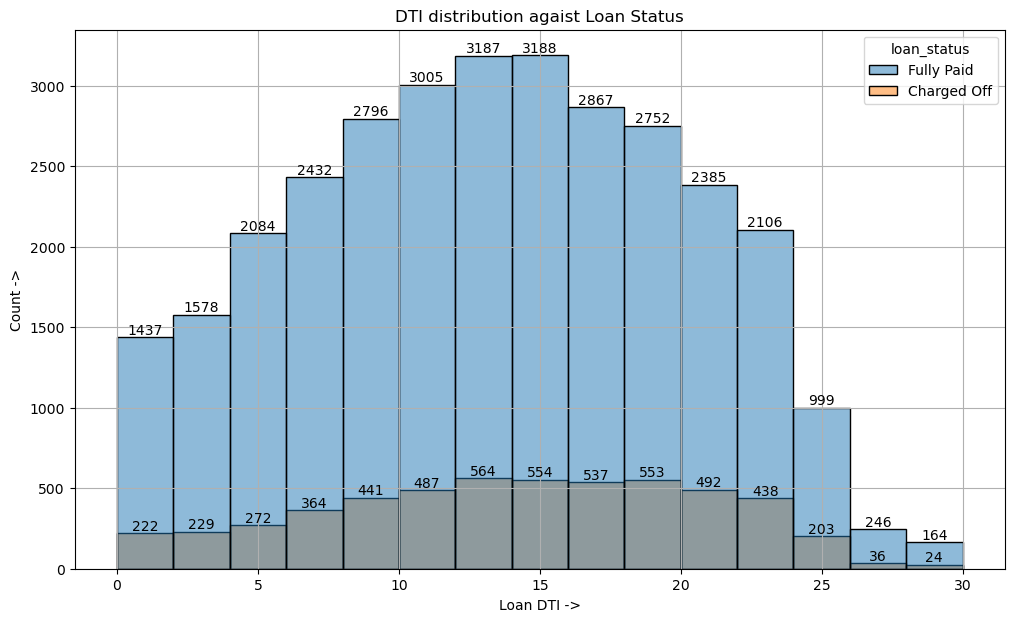

In [142]:
from IPython.core.display import display, HTML
display(HTML("<style>div.output_scroll { height: 45em; }</style>"))

plt.figure(figsize=(12,7))

ax = sns.histplot(data=lccs_df,x="dti",hue="loan_status",bins=15)
plt.title("DTI distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Loan DTI ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

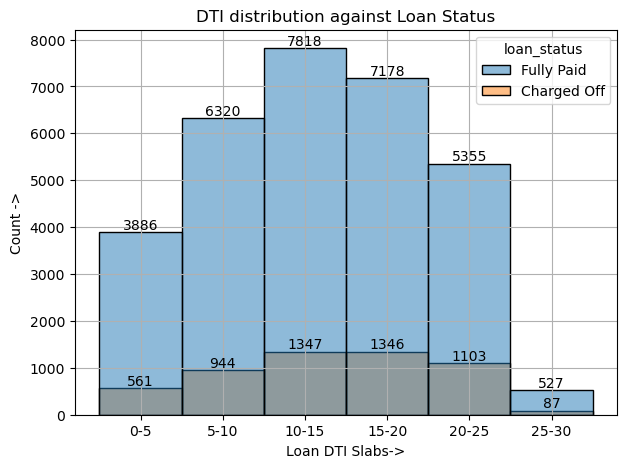

In [143]:
from IPython.core.display import display, HTML
display(HTML("<style>div.output_scroll { height: 45em; }</style>"))

plt.figure(figsize=(7,5))

ax = sns.histplot(data=lccs_df,x="dti_slabs",hue="loan_status")
plt.title("DTI distribution against Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Loan DTI Slabs->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

In [144]:
dti_vs_loan_status_df = pd.crosstab(lccs_df["dti_slabs"], lccs_df["loan_status"])
dti_vs_loan_status_df["Total"] = dti_vs_loan_status_df["Charged Off"] + dti_vs_loan_status_df["Fully Paid"]
dti_vs_loan_status_df["Perc_Charged_Off"] = round(((dti_vs_loan_status_df["Charged Off"])
                                                          /(dti_vs_loan_status_df["Total"])*100),2)
dti_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
dti_slabs,,,,
0-5,561,3886,4447,12.62
5-10,944,6320,7264,13.00
10-15,1347,7818,9165,14.70
15-20,1346,7178,8524,15.79
20-25,1103,5355,6458,17.08
25-30,87,527,614,14.17


In [145]:
dti_vs_loan_status_df.reset_index(inplace=True)

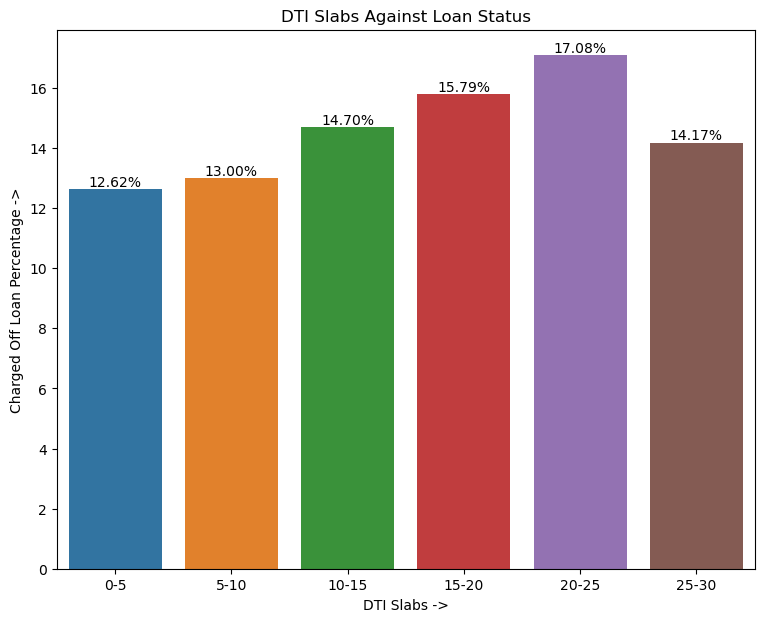

In [146]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=dti_vs_loan_status_df,x="dti_slabs",y="Perc_Charged_Off")

plt.bar_label(ax.containers[0],fmt='%.2f%%',label_type="edge")
plt.title("DTI Slabs Against Loan Status")
plt.xlabel("DTI Slabs ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

## <font color = green> Observations on bivariate analysis: "dti" vs "loan_status"
> 1. Above results point to a strong relationship between "dti" and "loan_status"
> 2. For "dti" between 10 to 25 the loan default rates too are found to be high (Compared to the total loans availed)
> 3. Higher "dti" value points to higher probability of the loan going default.

***

>>> ### <font color = blue> Bivariate analysis: "annual_inc" vs "loan_status"

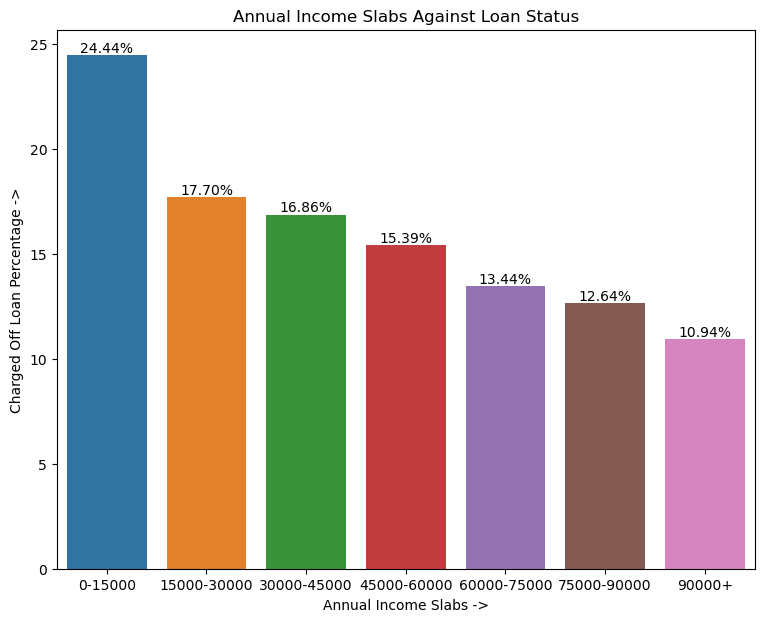

In [147]:
annual_inc_vs_loan_status_df = pd.crosstab(lccs_df["annual_inc_slabs"], lccs_df["loan_status"])
annual_inc_vs_loan_status_df["Total"] = annual_inc_vs_loan_status_df["Charged Off"] + annual_inc_vs_loan_status_df["Fully Paid"]
annual_inc_vs_loan_status_df["Perc_Charged_Off"] = round(((annual_inc_vs_loan_status_df["Charged Off"])
                                                          /(annual_inc_vs_loan_status_df["Total"])*100),2)
annual_inc_vs_loan_status_df

annual_inc_vs_loan_status_df.reset_index(inplace=True)

plt.figure(figsize=(9,7))
ax = sns.barplot(data=annual_inc_vs_loan_status_df,x="annual_inc_slabs",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.2f%%',label_type="edge")
plt.title("Annual Income Slabs Against Loan Status")
plt.xlabel("Annual Income Slabs ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "annual_inc" vs "loan_status"
> 1. Higher annual income leads to lesser probability of loan being defaulted upon

***

>>> ### <font color = blue> Bivariate analysis: "home_ownership" vs "loan_status"

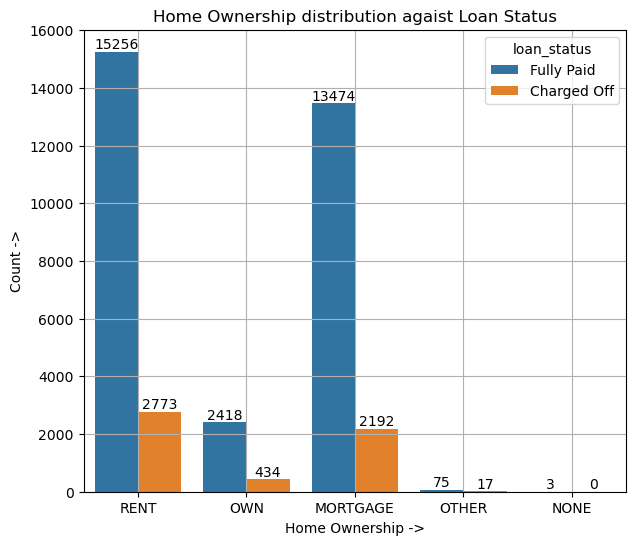

In [148]:
from IPython.core.display import display, HTML
display(HTML("<style>div.output_scroll { height: 45em; }</style>"))

plt.figure(figsize=(7,6))

ax = sns.countplot(data=lccs_df,x="home_ownership",hue="loan_status")
plt.title("Home Ownership distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Home Ownership ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()

plt.show()

In [149]:
home_ownership_vs_loan_status_df = pd.crosstab(lccs_df["home_ownership"], lccs_df["loan_status"])
home_ownership_vs_loan_status_df["Total"] = home_ownership_vs_loan_status_df["Charged Off"] + home_ownership_vs_loan_status_df["Fully Paid"]
home_ownership_vs_loan_status_df["Perc_Charged_Off"] = round(((home_ownership_vs_loan_status_df["Charged Off"])
                                                          /(home_ownership_vs_loan_status_df["Total"])*100),2)

home_none_df = home_ownership_vs_loan_status_df[(home_ownership_vs_loan_status_df.index == 'NONE')].index
home_ownership_vs_loan_status_df.drop(home_none_df , inplace=True)
home_ownership_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
home_ownership,,,,
MORTGAGE,2192,13474,15666,13.99
OTHER,17,75,92,18.48
OWN,434,2418,2852,15.22
RENT,2773,15256,18029,15.38


In [150]:
home_ownership_vs_loan_status_df.reset_index(inplace=True)

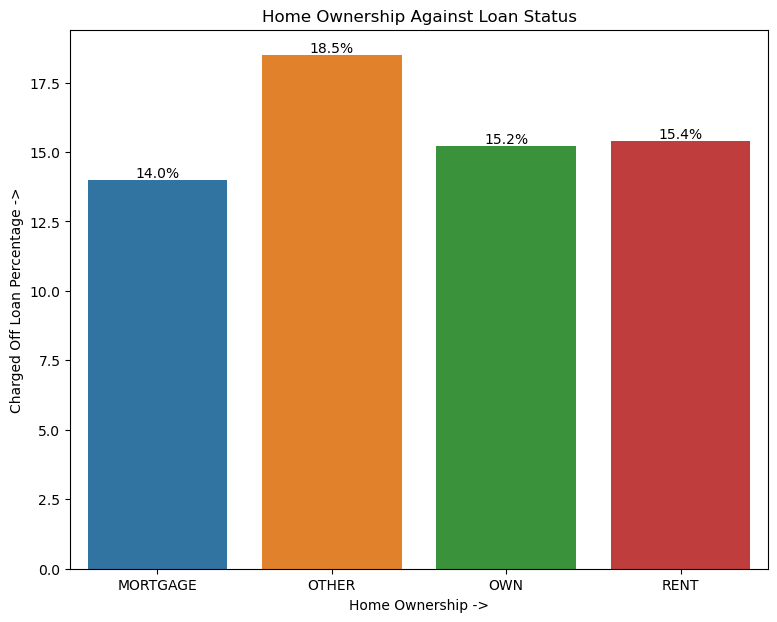

In [151]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=home_ownership_vs_loan_status_df,x="home_ownership",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.1f%%',label_type="edge")
plt.title("Home Ownership Against Loan Status")
plt.xlabel("Home Ownership ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "home_ownership" vs "loan_status"
> 1. Above results convey that the probability of having a own home does not mean the loans are not defaulted
> 2. No strong relationship found between loan status and home ownership metrics

***

>>> ### <font color = blue> Bivariate analysis: "int_rate" vs "loan_status"

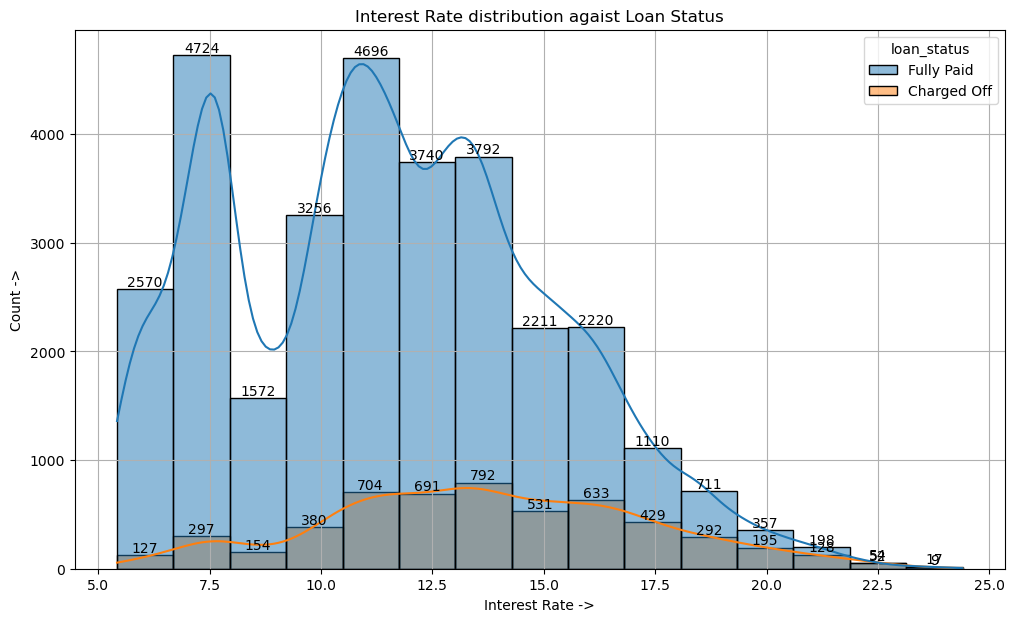

In [152]:
plt.figure(figsize=(12,7))

# sns.countplot(data=lccs_df,x="int_rate",hue="loan_status")
ax = sns.histplot(data=lccs_df, x="int_rate", hue="loan_status", kde=True, bins=15)
plt.title("Interest Rate distribution agaist Loan Status")
ax.bar_label(ax.containers[0])
plt.xlabel("Interest Rate ->")
ax.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

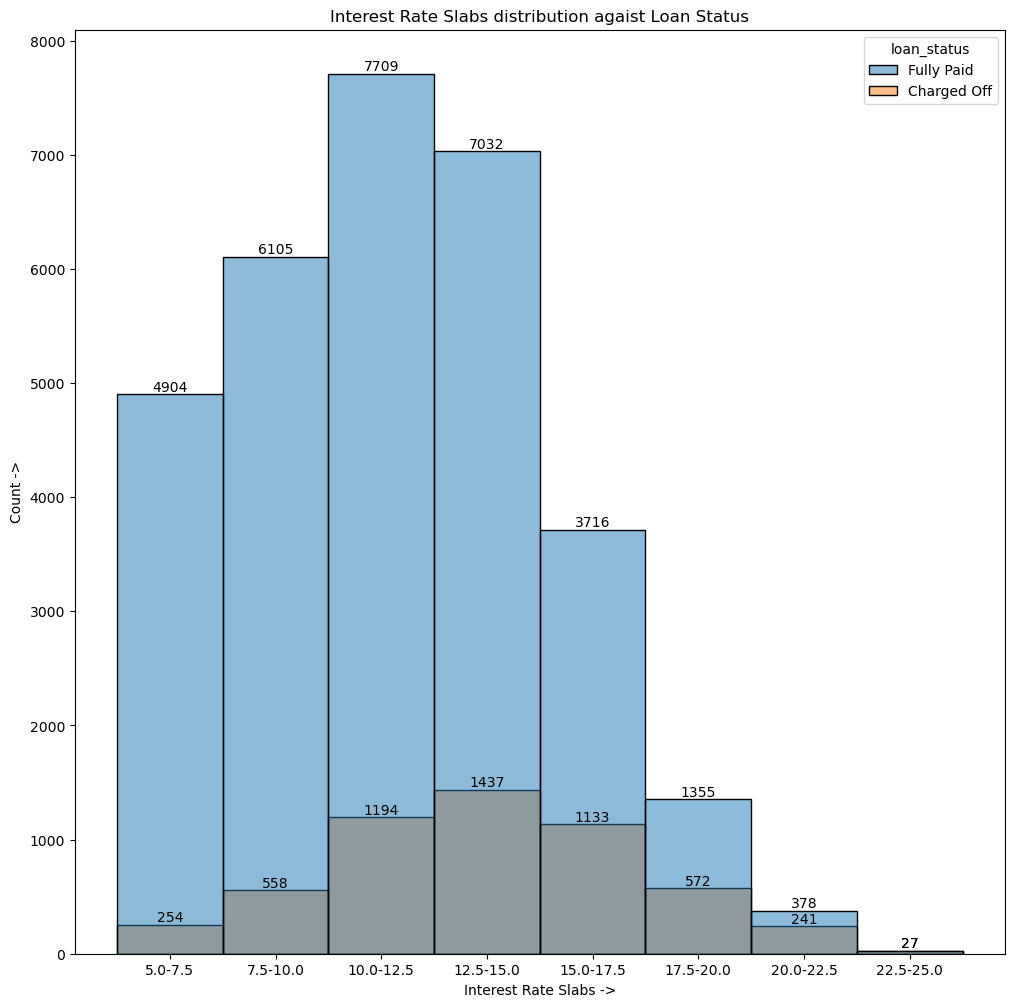

In [153]:
plt.figure(figsize=(12,12))

# sns.countplot(data=lccs_df,x="int_rate",hue="loan_status")
ax = sns.histplot(data=lccs_df, x="int_rate_slabs", hue="loan_status")
plt.title("Interest Rate Slabs distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Interest Rate Slabs ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.show()

In [154]:
int_rate_vs_loan_status_df = pd.crosstab(lccs_df["int_rate_slabs"], lccs_df["loan_status"])
int_rate_vs_loan_status_df["Total"] = int_rate_vs_loan_status_df["Charged Off"] + int_rate_vs_loan_status_df["Fully Paid"]
int_rate_vs_loan_status_df["Perc_Charged_Off"] = round(((int_rate_vs_loan_status_df["Charged Off"])
                                                          /(int_rate_vs_loan_status_df["Total"])*100),2)

int_rate_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
int_rate_slabs,,,,
5.0-7.5,254,4904,5158,4.92
7.5-10.0,558,6105,6663,8.37
10.0-12.5,1194,7709,8903,13.41
12.5-15.0,1437,7032,8469,16.97
15.0-17.5,1133,3716,4849,23.37
17.5-20.0,572,1355,1927,29.68
20.0-22.5,241,378,619,38.93
22.5-25.0,27,27,54,50.00


In [155]:
int_rate_vs_loan_status_df.reset_index(inplace=True)

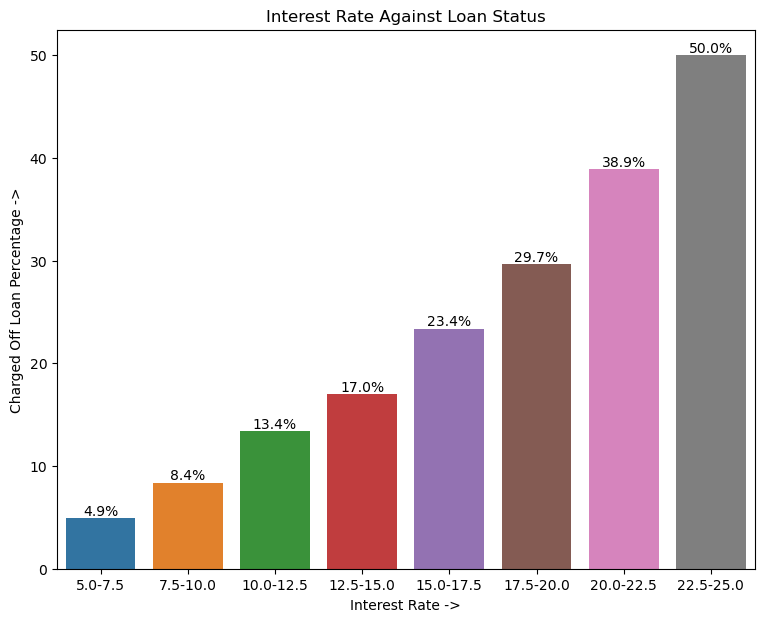

In [156]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=int_rate_vs_loan_status_df,x="int_rate_slabs",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.1f%%',label_type="edge")
plt.title("Interest Rate Against Loan Status")
plt.xlabel("Interest Rate ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "int_rate" vs "loan_status"
> 1. Above results convey that the probability of loan being defaulted increases with interest rate. This holds true until the interest rate of around 18%. However, default rate again increases as teh loan interest rate increases beyond 18%.
> 2. At median level, probabilty of a loan going default increases with interest rate

***

>>> ### <font color = blue> Bivariate analysis: "purpose" vs "loan_status"

In [157]:
purpose_vs_loan_status_df = pd.crosstab(lccs_df["purpose"], lccs_df["loan_status"])
purpose_vs_loan_status_df["Total"] = purpose_vs_loan_status_df["Charged Off"] + purpose_vs_loan_status_df["Fully Paid"]
purpose_vs_loan_status_df["Perc_Charged_Off"] = round(((purpose_vs_loan_status_df["Charged Off"])
                                                       /(purpose_vs_loan_status_df["Total"])*100),1)

purpose_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
purpose,,,,
car,159,1289,1448,11.0
credit_card,519,4263,4782,10.9
debt_consolidation,2675,14626,17301,15.5
educational,54,258,312,17.3
home_improvement,322,2233,2555,12.6
house,55,283,338,16.3
major_purchase,217,1828,2045,10.6
medical,104,536,640,16.2
moving,90,460,550,16.4


In [158]:
purpose_vs_loan_status_df.reset_index(inplace=True)

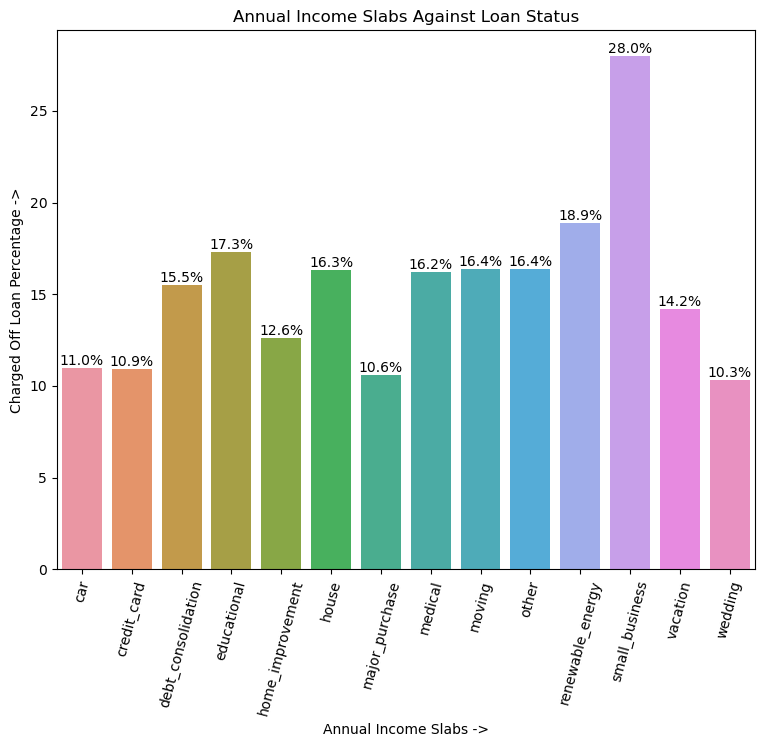

In [159]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=purpose_vs_loan_status_df,x="purpose",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.1f%%',label_type="edge")
plt.title("Annual Income Slabs Against Loan Status")
plt.xlabel("Annual Income Slabs ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.xticks(rotation=75)
plt.show()

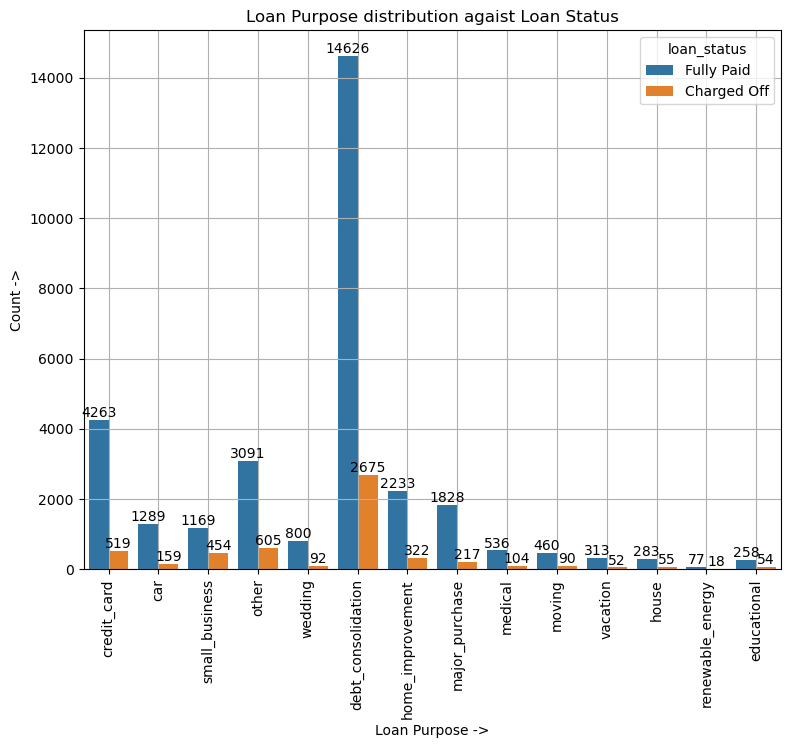

In [160]:
plt.figure(figsize=(9,7))

ax = sns.countplot(data=lccs_df,x="purpose",hue="loan_status",orient='v')
plt.title("Loan Purpose distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Loan Purpose ->")
plt.xticks(rotation = 90)
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

### <font color = green> Observations on bivariate analysis: "purpose" vs "loan_status"
> 1. Above results convey that "debt_consoliadation" is the biggest reason for borrowing loan and also is the biggest contributor for the loan default rate
   
> 2. "debt_consolidation" and "credit_card" are the main purpose for borrowing loan and contribute more to the loan defaults. Hence, institutions need to be careful while providing loan for something which involves clearing off the existing debts.
    
> 3. Loans for "small business" purpose has the highest default rate

***

>>> ### <font color = blue> Bivariate analysis: "emp_length" vs "loan_status"

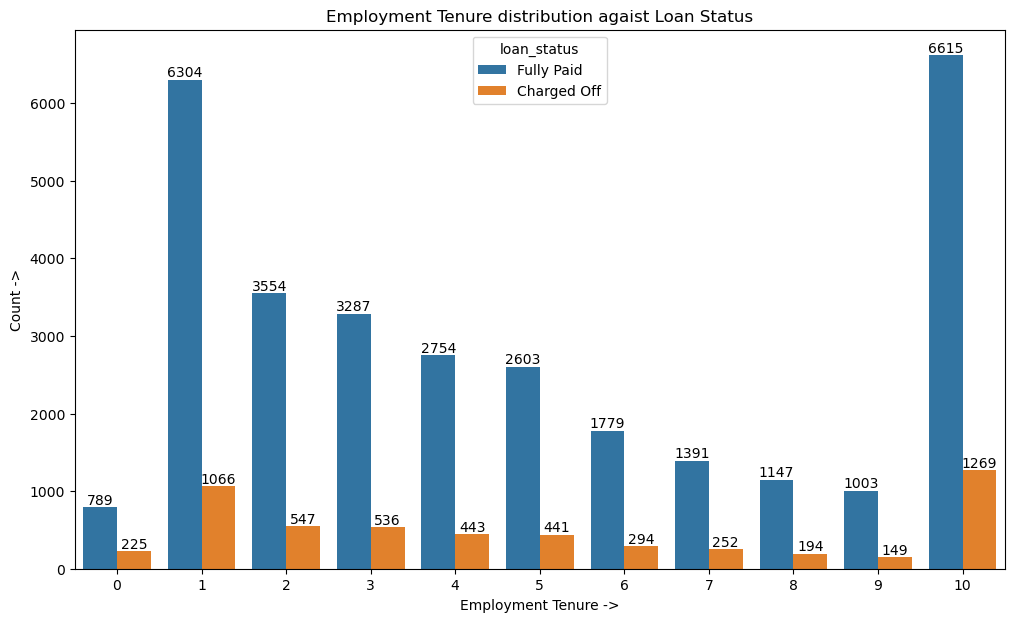

In [161]:
plt.figure(figsize=(12,7))

ax = sns.countplot(data=lccs_df,x="emp_length",hue="loan_status")
# sns.histplot(data=lccs_df, x="emp_length", hue="loan_status", kde=True, bins=15)
plt.title("Employment Tenure distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Employment Tenure ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.show()

## <font color = green> Observations on bivariate analysis: "emp_length" vs "loan_status"
> 1. No strong relationship is found between "loan_status" and "emp_length"
> 2. It looks initially that the defaulting probability is high for "emp_length" 1 or less and 10 or more but then the borrowers in the same range have highest probability of fully paying off their loans

***

>>> ### <font color = blue> Bivariate analysis: "grade" vs "loan_status"

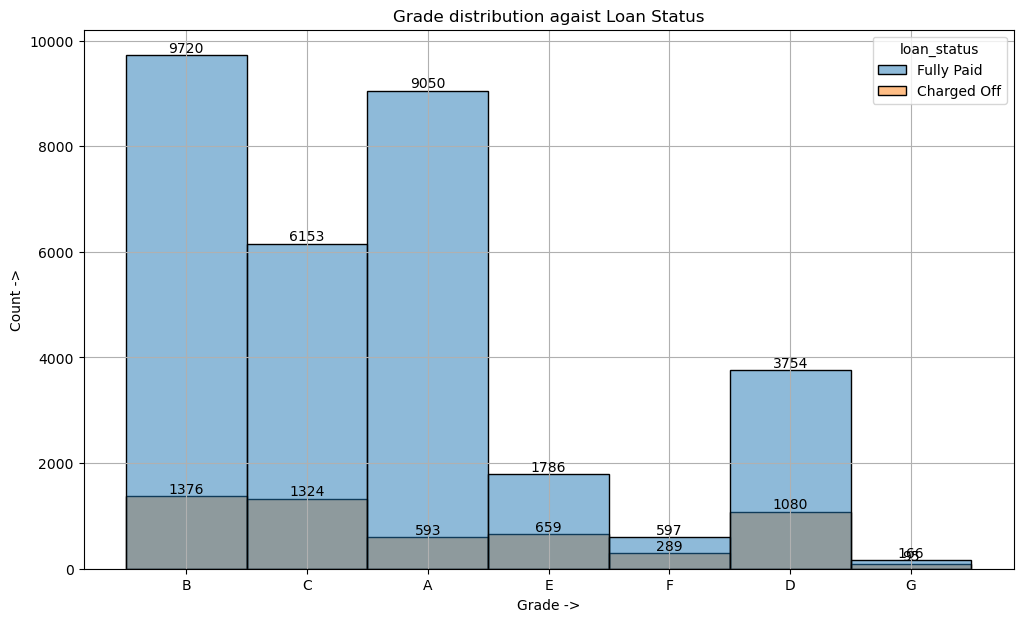

In [162]:
from IPython.core.display import display, HTML
display(HTML("<style>div.output_scroll { height: 45em; }</style>"))

plt.figure(figsize=(12,7))

# sns.countplot(data=lccs_df,x="int_rate",hue="loan_status")
ax = sns.histplot(data=lccs_df, x="grade", hue="loan_status", bins=15)
plt.title("Grade distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Grade ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

In [163]:
grade_vs_loan_status_df = pd.crosstab(lccs_df["grade"], lccs_df["loan_status"])
grade_vs_loan_status_df["Total"] = grade_vs_loan_status_df["Charged Off"] + grade_vs_loan_status_df["Fully Paid"]
grade_vs_loan_status_df["Perc_Charged_Off"] = round(((grade_vs_loan_status_df["Charged Off"])
                                                          /(grade_vs_loan_status_df["Total"])*100),2)

grade_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
grade,,,,
A,593,9050,9643,6.15
B,1376,9720,11096,12.40
C,1324,6153,7477,17.71
D,1080,3754,4834,22.34
E,659,1786,2445,26.95
F,289,597,886,32.62
G,95,166,261,36.40


In [164]:
grade_vs_loan_status_df.reset_index(inplace=True)

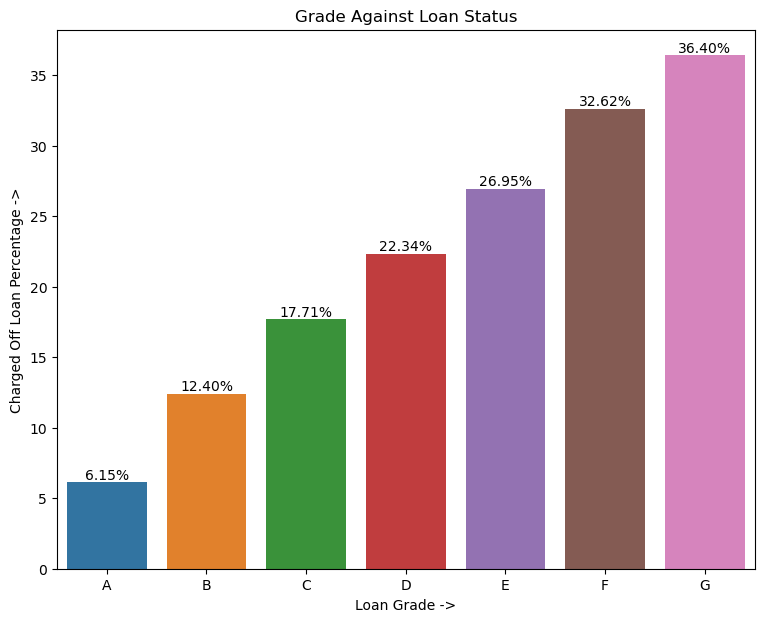

In [165]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=grade_vs_loan_status_df,x="grade",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.2f%%',label_type="edge")
plt.title("Grade Against Loan Status")
plt.xlabel("Loan Grade ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "grade" vs "loan_status"
> 1. Above results convey that the probabiolity of loan being defaulted increases with interest rate. This holds true until the interest rate of around 18%
> 2. At median level, probabilty of a loan going default increases with interest rate

***

>>> ### <font color = blue> Bivariate analysis: "pub_rec_bankruptcies" vs "loan_status"

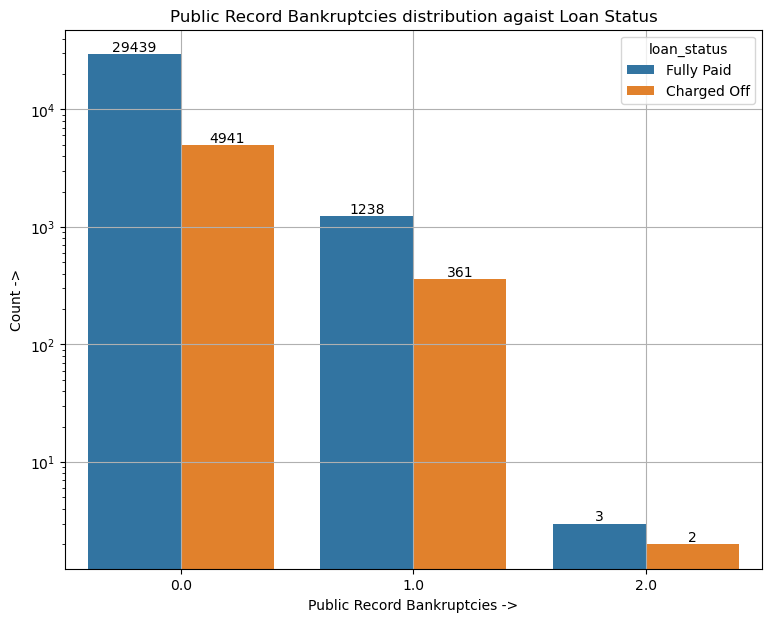

In [166]:
plt.figure(figsize=(9,7))

ax = sns.countplot(data=lccs_df,x="pub_rec_bankruptcies",hue="loan_status")
ax.set_yscale('log'
             )
plt.title("Public Record Bankruptcies distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Public Record Bankruptcies ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

In [167]:
pub_rec_bank_vs_loan_status_df = pd.crosstab(lccs_df["pub_rec_bankruptcies"], lccs_df["loan_status"])
pub_rec_bank_vs_loan_status_df["Total"] = pub_rec_bank_vs_loan_status_df["Charged Off"] + pub_rec_bank_vs_loan_status_df["Fully Paid"]
pub_rec_bank_vs_loan_status_df["Perc_Charged_Off"] = round(((pub_rec_bank_vs_loan_status_df["Charged Off"])
                                                          /(pub_rec_bank_vs_loan_status_df["Total"])*100),2)
pub_rec_bank_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
pub_rec_bankruptcies,,,,
0.0,4941,29439,34380,14.37
1.0,361,1238,1599,22.58
2.0,2,3,5,40.00


In [168]:
pub_rec_bank_vs_loan_status_df.reset_index(inplace=True)

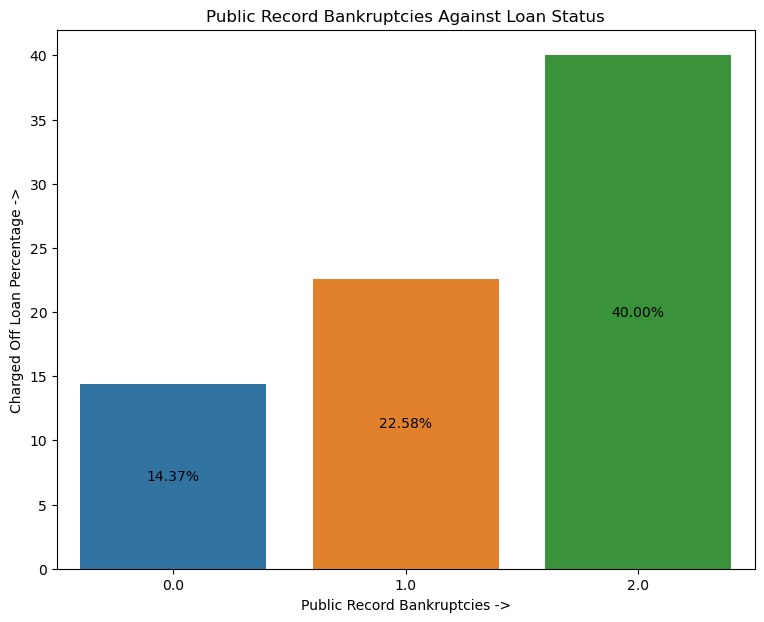

In [169]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=pub_rec_bank_vs_loan_status_df,x="pub_rec_bankruptcies",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.2f%%',label_type="center")
plt.title("Public Record Bankruptcies Against Loan Status")
plt.xlabel("Public Record Bankruptcies ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

## <font color = green> Observations on bivariate analysis: "pub_rec_bankruptcies" vs "loan_status"
> 1. Borrowers with no public records for bankruptcies have higher probability of fully paying off the loan
> 2. Higher "pub_rec_bankruptcies" means higher the chances of the loan going default

***

>>> ### <font color = blue> Bivariate analysis: "annual_inc" vs "loan_status"

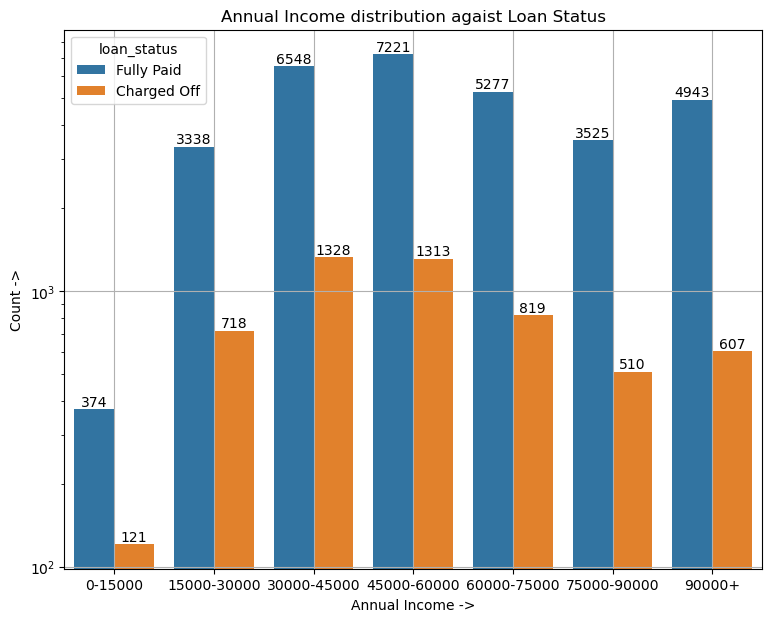

In [170]:
plt.figure(figsize=(9,7))

ax = sns.countplot(data=lccs_df,x="annual_inc_slabs",hue="loan_status")
ax.set_yscale('log')
plt.title("Annual Income distribution agaist Loan Status")
plt.bar_label(ax.containers[0])
plt.xlabel("Annual Income ->")
plt.bar_label(ax.containers[1])
plt.ylabel("Count ->")
plt.grid()
plt.show()

In [171]:
annual_inc_vs_loan_status_df = pd.crosstab(lccs_df["annual_inc_slabs"], lccs_df["loan_status"])
annual_inc_vs_loan_status_df["Total"] = annual_inc_vs_loan_status_df["Charged Off"] + annual_inc_vs_loan_status_df["Fully Paid"]
annual_inc_vs_loan_status_df["Perc_Charged_Off"] = round(((annual_inc_vs_loan_status_df["Charged Off"])
                                                          /(annual_inc_vs_loan_status_df["Total"])*100),2)
annual_inc_vs_loan_status_df

loan_status,Charged Off,Fully Paid,Total,Perc_Charged_Off
annual_inc_slabs,,,,
0-15000,121,374,495,24.44
15000-30000,718,3338,4056,17.70
30000-45000,1328,6548,7876,16.86
45000-60000,1313,7221,8534,15.39
60000-75000,819,5277,6096,13.44
75000-90000,510,3525,4035,12.64
90000+,607,4943,5550,10.94


In [172]:
annual_inc_vs_loan_status_df.reset_index(inplace=True)

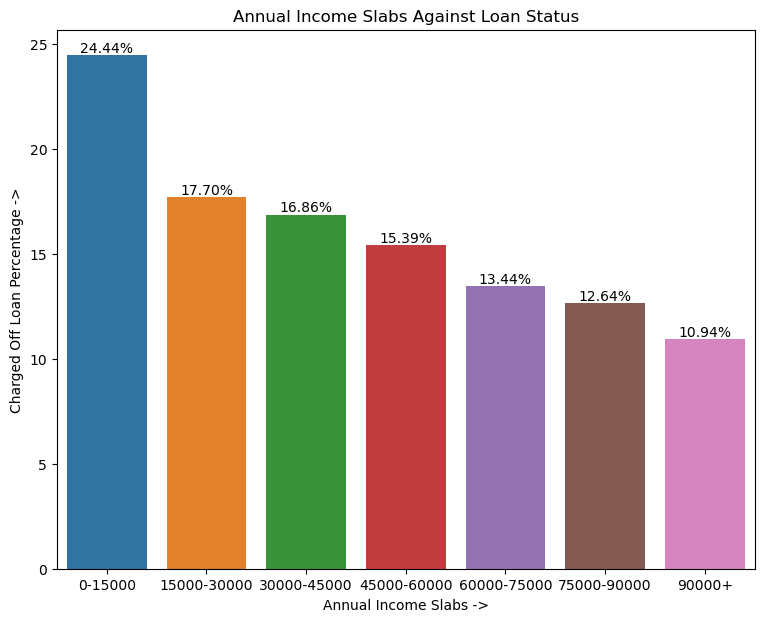

In [173]:
plt.figure(figsize=(9,7))
ax = sns.barplot(data=annual_inc_vs_loan_status_df,x="annual_inc_slabs",y="Perc_Charged_Off")
plt.bar_label(ax.containers[0],fmt='%.2f%%',label_type="edge")
plt.title("Annual Income Slabs Against Loan Status")
plt.xlabel("Annual Income Slabs ->")
plt.ylabel("Charged Off Loan Percentage ->")
plt.show()

### <font color = green> Observations on bivariate analysis: "annual_inc" vs "loan_status"
> 1. Analysis was done on annual income by binning it into slabs
> 2. It is observed that as annual income increases the changes of the loan going default decreases.

***

>>> ## CONCLUSIONS

 
## <font color = green> Low Risk Factors:
### Observations -
    
- Amount in the range of 5000 to 14,000
- For borrowers with annual income greater than 90,000
- For purposes like weddings, car purchase, credit card are low risk
- Which can be disbursed under Grade-'A' or Grade-'B'
- For borrowers with their DTI score less than or equal to 10
- For borrowers with their public bankruptcy record count being 0
    
### Recommendations - 
- Loan requests meeting 3 or more of the above points can be considered to be a  medium risk
- Loan requests meeting all factors are best fit for loan acceptance

## <font color = green> High Risk Factors:
    
### Observations - 
- Amount greater than 21,000
- For borrowers with annual income less than 45,000
- For purposes like small business, renewable energy and educational
- Which need to be approved only under Grade-'D', Grade-'E', Grade-'F' and Grade-'G'
- For borrowers with their DTI score 2.
- For borrowers with DTI score greater than 2 are best avoided
- For borrowers with their public bankruptcy record count greater than 0
    
### Recommendations - 
- Loan requests meeting 3 or more of the above points will have a higher chance of defaulting
- Loan requests meeting all the above factors should not be considered for loan acceptance

***